## **Library Imports - 15-minute horizon**

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import logging
from scipy import stats
import seaborn as sns
from scipy.stats import ks_2samp
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import time
import joblib
import statsmodels.api as sm

# Add the parent directory to Python's path
sys.path.append(os.path.abspath('..'))

from sklearn.preprocessing import StandardScaler

# Import your custom modules
import src.config as config
from src.model_prep_tools import create_multivariate_sequences, flatten_for_ml
from src.model_architectures import run_power_lstm, run_vanilla_transformer, run_keras_patchtst, run_chronos_univariate, run_chronos2_multivariate_v2
from src.ml_baselines import xgboost_implementation, rf_implementation, run_daily_naive
from src.evaluation_utils import save_experiment_results, plot_predictions, calculate_metrics, plot_hourly_error_heatmap, plot_uncertainty_bounds, run_all_residual_diagnostics, evaluate_statistical_significance,run_statistical_significance_tests

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')


# 15-MINUTE HORIZON CONFIGURATION

HORIZON_NAME = "15_min"
HORIZON_STEPS = 96
SEQ_LENGTH = 96
RANDOM_SEED = 2026
config.ACTIVE_HORIZON = HORIZON_NAME
config.NATIVE_FREQUENCY_MINUTES = config.FORECAST_HORIZONS[HORIZON_NAME]
config.SEQUENCE_LENGTH = HORIZON_STEPS

# Lock all environments using our centralized config tool!
config.set_global_seeds(RANDOM_SEED)

2026-06-15 21:41:00,981	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-15 21:41:01,355	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.



Global random seeds set to 2026


### **Data Load, Split, fit scaler and MIMO sequence**

In [2]:
# LOAD DATA
df_master = pd.read_parquet('../data/processed/nanogrid_15min_features.parquet')
TARGET_COL = config.TARGET_COL

# DEEP LEARNING PREP (Needs 3D continuous sequences)
dl_features = [TARGET_COL] + config.FEATURE_SETS["DEEP_LEARNING"]
df_dl = df_master[dl_features].copy()
dl_target_idx = df_dl.columns.get_loc(TARGET_COL)

# TREE PREP (Needs current snapshot + engineered lags)
tree_features = [TARGET_COL] + config.FEATURE_SETS["TREE_MODELS"]
df_tree = df_master[tree_features].copy()

# Split Indices (Strictly Chronological 70/10/20)
total_rows = len(df_master)
train_idx = int(total_rows * 0.70)
val_idx = int(total_rows * 0.80)

print(f"Master Dataset: {df_master.shape}")
print(f"DL Matrix Features: {len(dl_features)}")
print(f"Tree Matrix Features: {len(tree_features)}")

Master Dataset: (53225, 22)
DL Matrix Features: 18
Tree Matrix Features: 18


In [3]:
SEQ_LENGTH = config.SEQUENCE_LENGTH
HORIZON_STEPS = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

# DEEP LEARNING SCALING & SEQUENCES
dl_scaler_feat = StandardScaler()
dl_scaler_targ = StandardScaler()
df_dl_scaled = df_dl.copy()

dl_feat_cols = [c for c in df_dl.columns if c != TARGET_COL]

# Fit strictly on train, Transform the entire column safely
dl_scaler_targ.fit(df_dl.iloc[:train_idx][[TARGET_COL]])
df_dl_scaled[TARGET_COL] = dl_scaler_targ.transform(df_dl[[TARGET_COL]])

dl_scaler_feat.fit(df_dl.iloc[:train_idx][dl_feat_cols])
df_dl_scaled[dl_feat_cols] = dl_scaler_feat.transform(df_dl[dl_feat_cols])

# Generate 3D Sequences
X_train_3d, y_train = create_multivariate_sequences(df_dl_scaled.iloc[:train_idx].values, dl_target_idx, SEQ_LENGTH, HORIZON_STEPS)
X_val_3d, y_val     = create_multivariate_sequences(df_dl_scaled.iloc[train_idx:val_idx].values, dl_target_idx, SEQ_LENGTH, HORIZON_STEPS)
X_test_3d, y_test   = create_multivariate_sequences(df_dl_scaled.iloc[val_idx:].values, dl_target_idx, SEQ_LENGTH, HORIZON_STEPS)


# TREE SCALING & T-ZERO SLICE
tree_scaler_feat = StandardScaler()
df_tree_scaled = df_tree.copy()
tree_feat_cols = [c for c in df_tree.columns if c != TARGET_COL]

# Fit strictly on train, Transform the entire column safely
tree_scaler_feat.fit(df_tree.iloc[:train_idx][tree_feat_cols])
df_tree_scaled[tree_feat_cols] = tree_scaler_feat.transform(df_tree[tree_feat_cols])

# Generate sequences to match y_targets perfectly, but only keep the T=0 row
X_train_tree_temp, _ = create_multivariate_sequences(df_tree_scaled.iloc[:train_idx].values, 0, SEQ_LENGTH, HORIZON_STEPS)
X_val_tree_temp, _   = create_multivariate_sequences(df_tree_scaled.iloc[train_idx:val_idx].values, 0, SEQ_LENGTH, HORIZON_STEPS)
X_test_tree_temp, _  = create_multivariate_sequences(df_tree_scaled.iloc[val_idx:].values, 0, SEQ_LENGTH, HORIZON_STEPS)

# The T-Zero Slice
X_train_tree = X_train_tree_temp[:, -1, :]
X_val_tree   = X_val_tree_temp[:, -1, :]
X_test_tree  = X_test_tree_temp[:, -1, :]

print(f"Deep Learning Inputs (3D): Train {X_train_3d.shape} | Val {X_val_3d.shape} | Test {X_test_3d.shape}")
print(f"Tree Inputs (2D): Train {X_train_tree.shape} | Val {X_val_tree.shape} | Test {X_test_tree.shape}")
print(f"Universal Targets (y): Train {y_train.shape} | Val {y_val.shape} | Test {y_test.shape}")

# Lock seeds
config.set_global_seeds(config.RANDOM_SEED)

# Validate the configuration!
config.validate_config()

Deep Learning Inputs (3D): Train (37066, 96, 18) | Val (5132, 96, 18) | Test (10454, 96, 18)
Tree Inputs (2D): Train (37066, 18) | Val (5132, 18) | Test (10454, 18)
Universal Targets (y): Train (37066, 96) | Val (5132, 96) | Test (10454, 96)
Global random seeds set to 2026
Configuration validation passed


In [4]:
if 'horizon_metrics' not in locals():
    horizon_metrics = []

# True to retrain
# False to load saved weights
TRAIN_FROM_SCRATCH = False

### **Naive Baseline** 
Predicts that tomorrow's 96-step sequence will be exactly identical 
    to the sequence from 24 hours (96 steps) ago.

Running Daily Naive Baseline
Daily_Naive_Baseline artifacts successfully saved to ../results/15_min/Daily_Naive_Baseline/


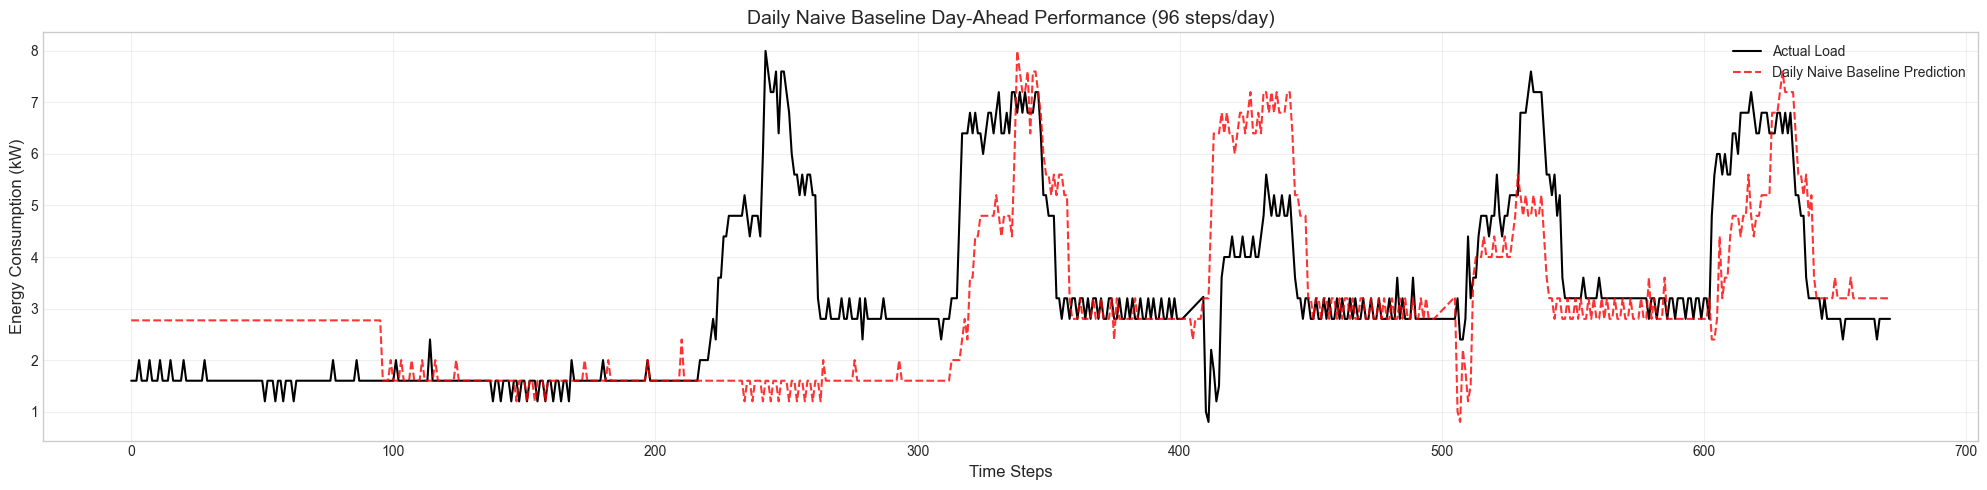

In [5]:
y_train_raw = df_master.iloc[:train_idx][TARGET_COL].values
orig_shape = y_test.shape
y_test_unscaled = dl_scaler_targ.inverse_transform(y_test.reshape(-1, 1)).reshape(orig_shape)

print("Running Daily Naive Baseline")

start_time = time.time()
naive_predictions = run_daily_naive(y_test_unscaled, horizon=HORIZON_STEPS)
exec_time = time.time() - start_time

naive_metrics = calculate_metrics(
    y_true=y_test_unscaled, 
    y_pred=naive_predictions, 
    model_name="Daily_Naive_Baseline", 
    execution_time=exec_time,
    horizon=HORIZON_STEPS, 
    y_train=y_train_raw
)

naive_results_dict = {
    "model": "Daily_Naive",
    "predictions": naive_predictions,
    "y_test_real": y_test_unscaled,
    "metrics": naive_metrics
}

save_experiment_results(
    results_dict=naive_results_dict, 
    model_name="Daily_Naive_Baseline", 
    horizon_name=HORIZON_NAME,
    y_test=y_test_unscaled, 
    horizon=HORIZON_STEPS
)

horizon_metrics.append(naive_metrics)

plot_predictions(
    y_true=y_test_unscaled, 
    y_pred=naive_predictions, 
    model_name="Daily Naive Baseline", 
    horizon=HORIZON_STEPS,
    num_steps=HORIZON_STEPS * 7
)

### **Tree-Based Baselines**
Utilizing Optuna Tuning


RUNNING XGBOOST_MAE (15_min) | Horizon: 96
Loading pre-trained model from ../results/15_min/XGBoost_MAE/xgboost_mae_model.joblib


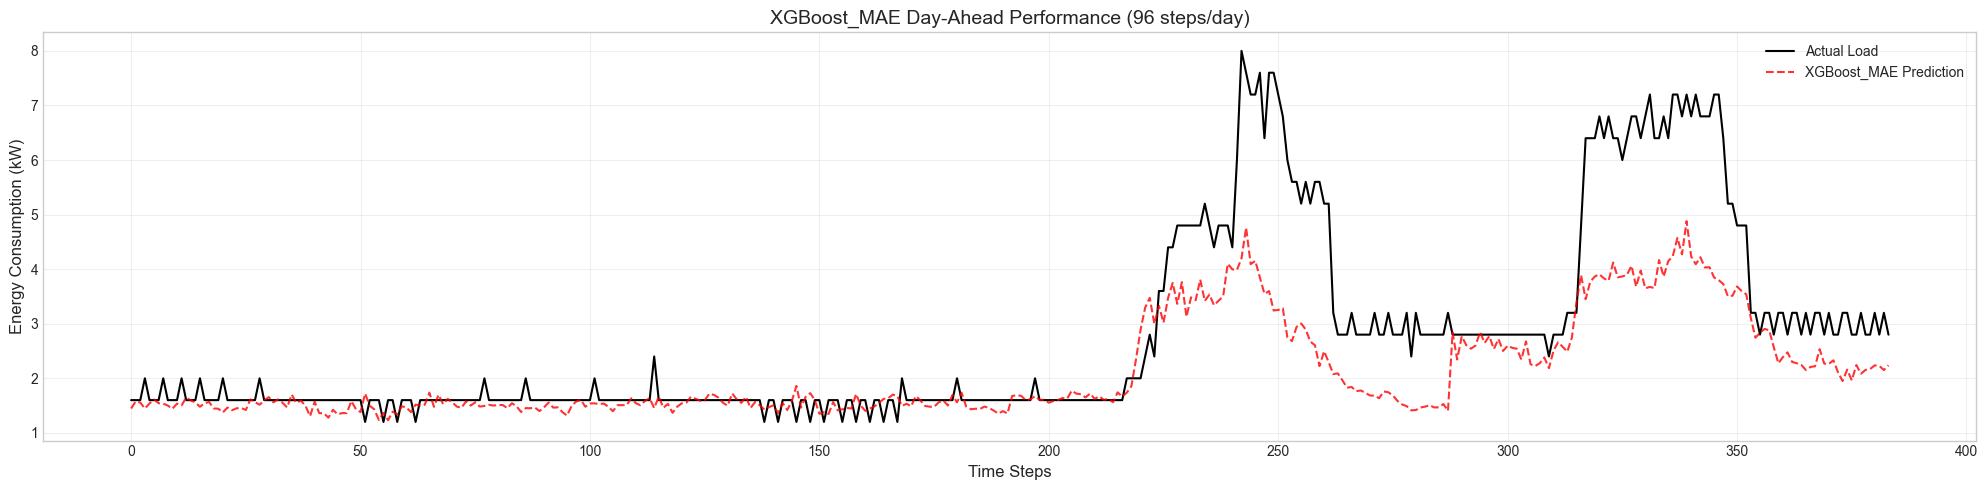

XGBoost_MAE artifacts successfully saved to ../results/15_min/XGBoost_MAE/

RUNNING XGBOOST_RMSE (15_min) | Horizon: 96
Loading pre-trained model from ../results/15_min/XGBoost_RMSE/xgboost_rmse_model.joblib


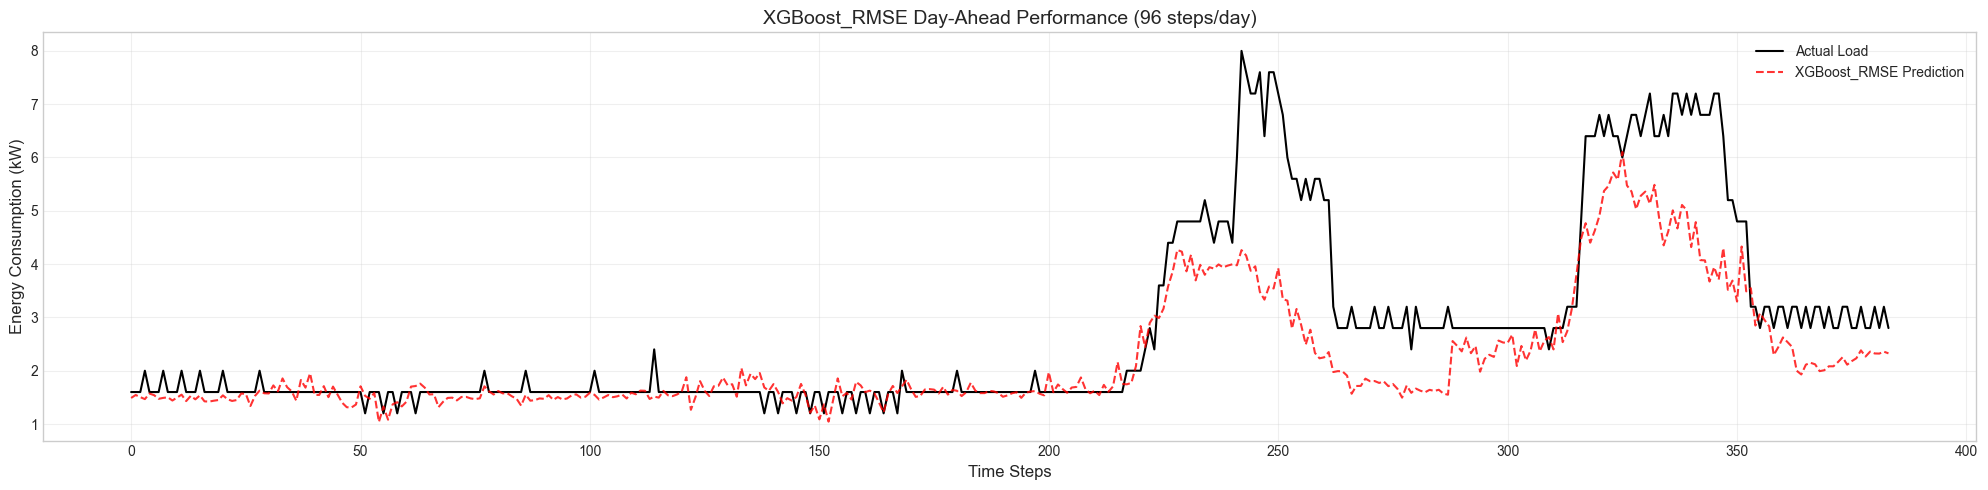

XGBoost_RMSE artifacts successfully saved to ../results/15_min/XGBoost_RMSE/

 RUNNING RANDOM_FOREST (15_min) | Horizon: 96
Loading pre-trained model from ../results/15_min/Random_Forest/random_forest_model.joblib


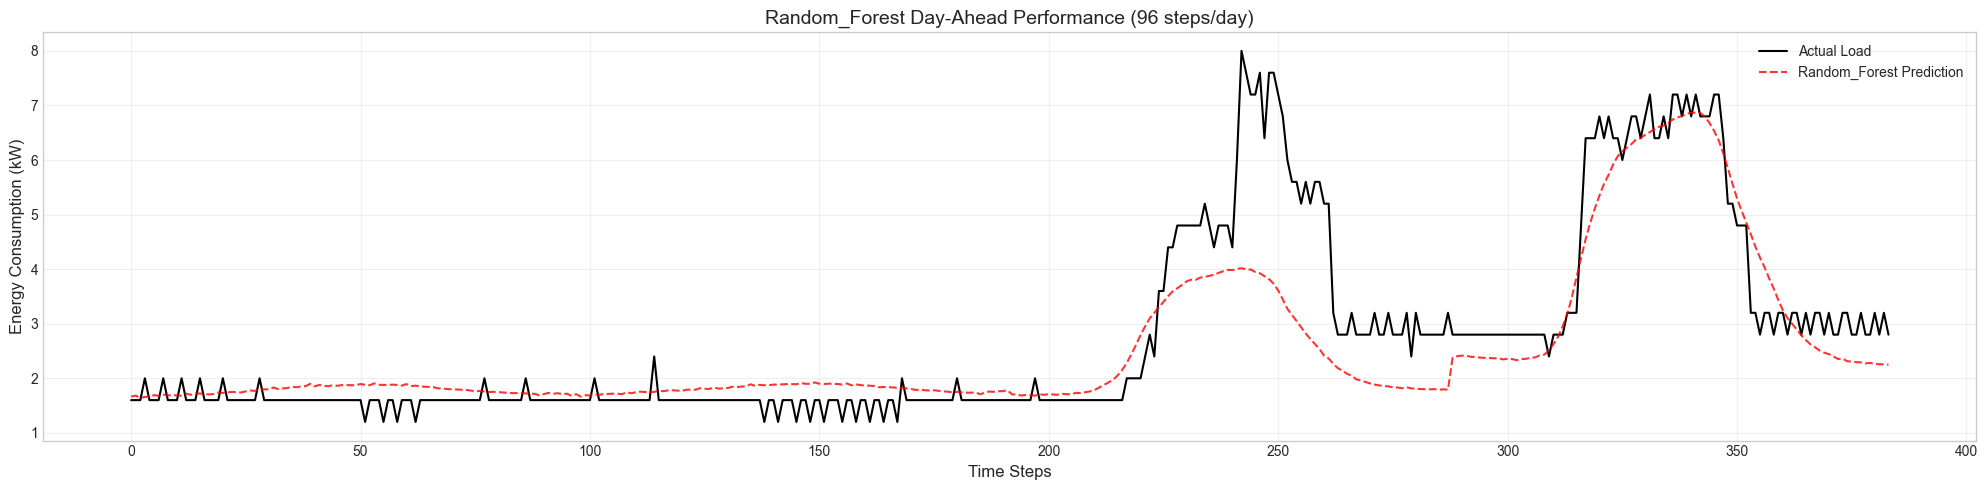

Random_Forest artifacts successfully saved to ../results/15_min/Random_Forest/


In [6]:
# XGBoost
xgboost_experiments = ["MAE", "RMSE"]
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for metric in xgboost_experiments:
    results = xgboost_implementation(
        X_train=X_train_tree, y_train=y_train, X_val=X_val_tree, y_val=y_val, X_test=X_test_tree, y_test=y_test,
        horizon_name=config.ACTIVE_HORIZON, y_train_full=y_train, target_scaler=dl_scaler_targ,
        target_feature_idx=dl_target_idx, optimization_metric=metric, train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    continuous_y_train_scaled = df_dl_scaled.iloc[:train_idx, dl_target_idx].values
    y_train_unscaled = dl_scaler_targ.inverse_transform(continuous_y_train_scaled.reshape(-1, 1)).flatten()
    old_time = results["metrics"]["Time (s)"]
    
    true_metrics = calculate_metrics(
        y_true=results['y_test_real'], y_pred=results['predictions'], 
        model_name=f"XGBoost_{metric}", execution_time=old_time, 
        horizon=horizon_val, y_train=y_train_unscaled
    )
    results["metrics"] = true_metrics
    
    save_experiment_results(results_dict=results, model_name=f"XGBoost_{metric}", horizon_name=config.ACTIVE_HORIZON, y_test=results['y_test_real'], horizon=horizon_val)
    horizon_metrics.append(true_metrics)

# Random Forest
results_rf = rf_implementation(
    X_train=X_train_tree, y_train=y_train, X_val=X_val_tree, y_val=y_val, X_test=X_test_tree, y_test=y_test,
    horizon_name=config.ACTIVE_HORIZON, y_train_full=y_train, target_scaler=dl_scaler_targ,
    target_feature_idx=dl_target_idx, train_from_scratch=TRAIN_FROM_SCRATCH
)

continuous_y_train_scaled = df_dl_scaled.iloc[:train_idx, dl_target_idx].values
y_train_unscaled = dl_scaler_targ.inverse_transform(continuous_y_train_scaled.reshape(-1, 1)).flatten()
old_time_rf = results_rf["metrics"]["Time (s)"]

true_metrics_rf = calculate_metrics(
    y_true=results_rf['y_test_real'], y_pred=results_rf['predictions'], 
    model_name="Random_Forest", execution_time=old_time_rf, 
    horizon=horizon_val, y_train=y_train_unscaled
)
results_rf["metrics"] = true_metrics_rf

save_experiment_results(results_dict=results_rf, model_name="Random_Forest", horizon_name=config.ACTIVE_HORIZON, y_test=results_rf['y_test_real'], horizon=horizon_val)
horizon_metrics.append(true_metrics_rf)

### 7-Day plots for tree models:


Loading XGBoost_MAE from cache...


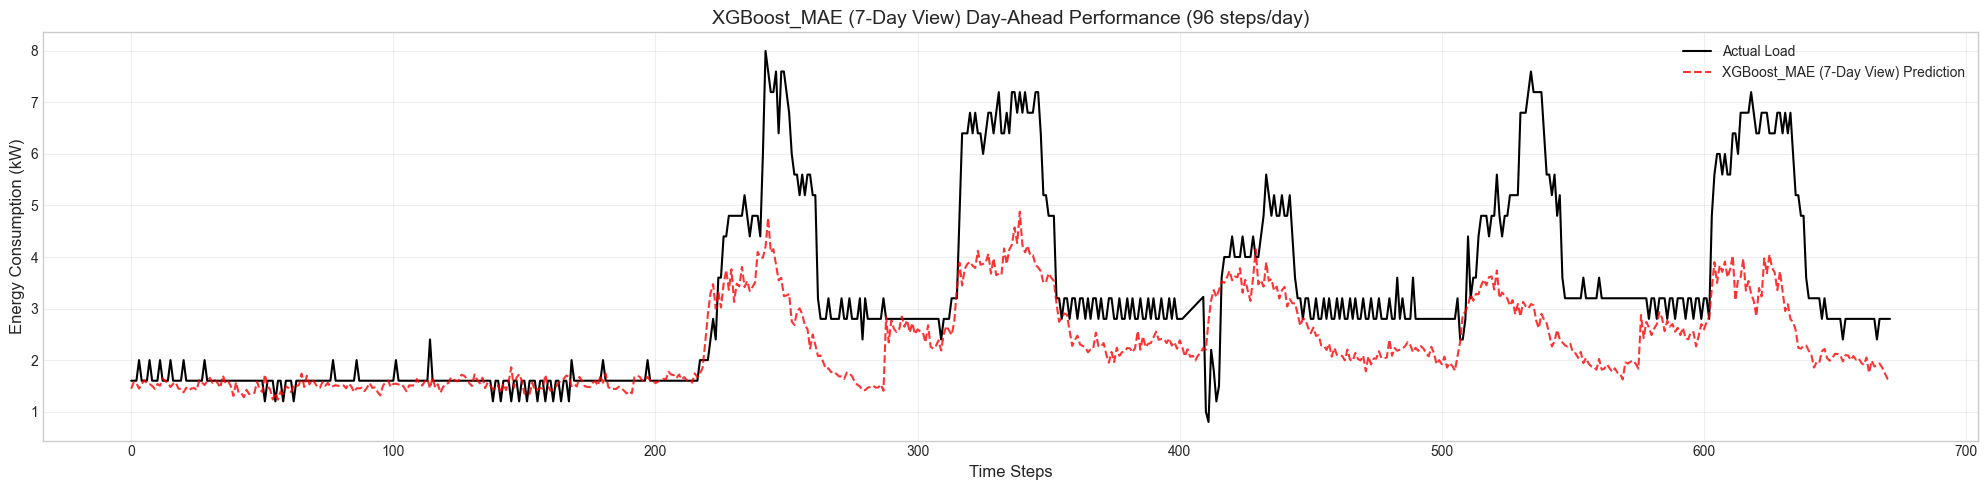


Loading XGBoost_RMSE from cache...


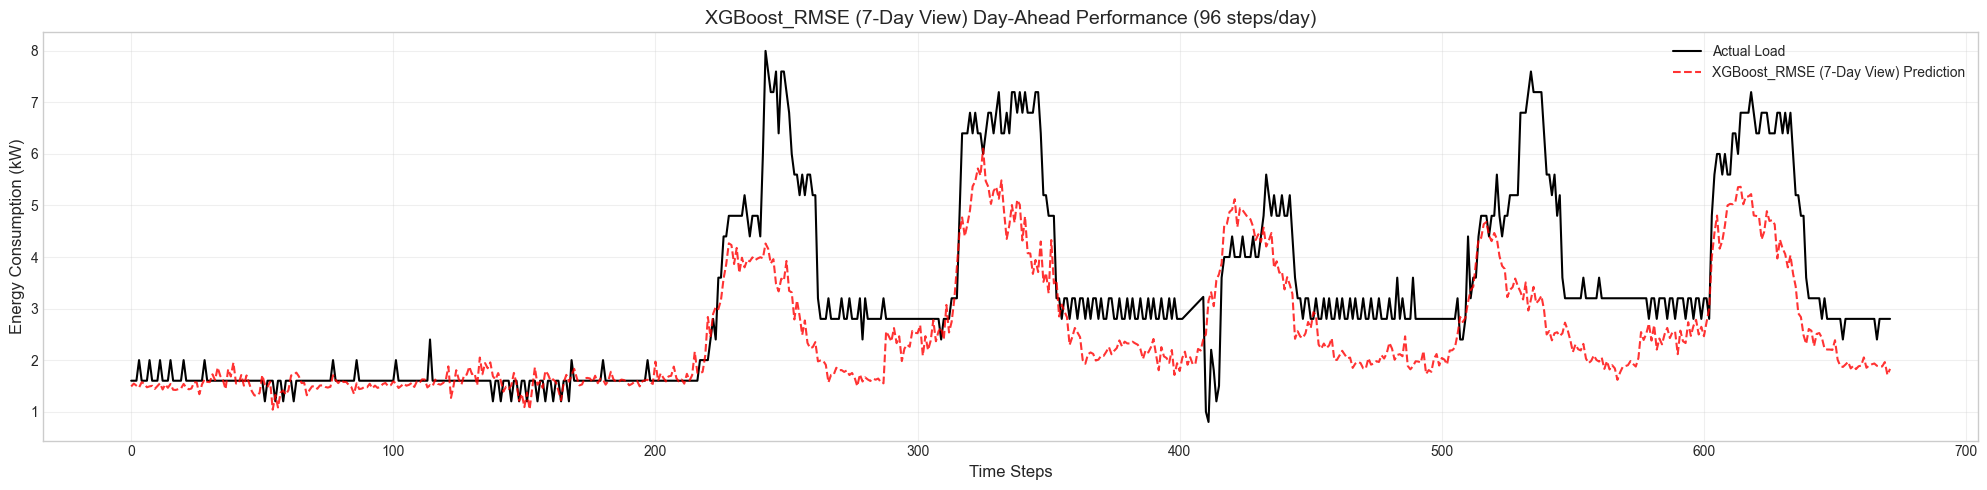


Loading Random_Forest from cache...


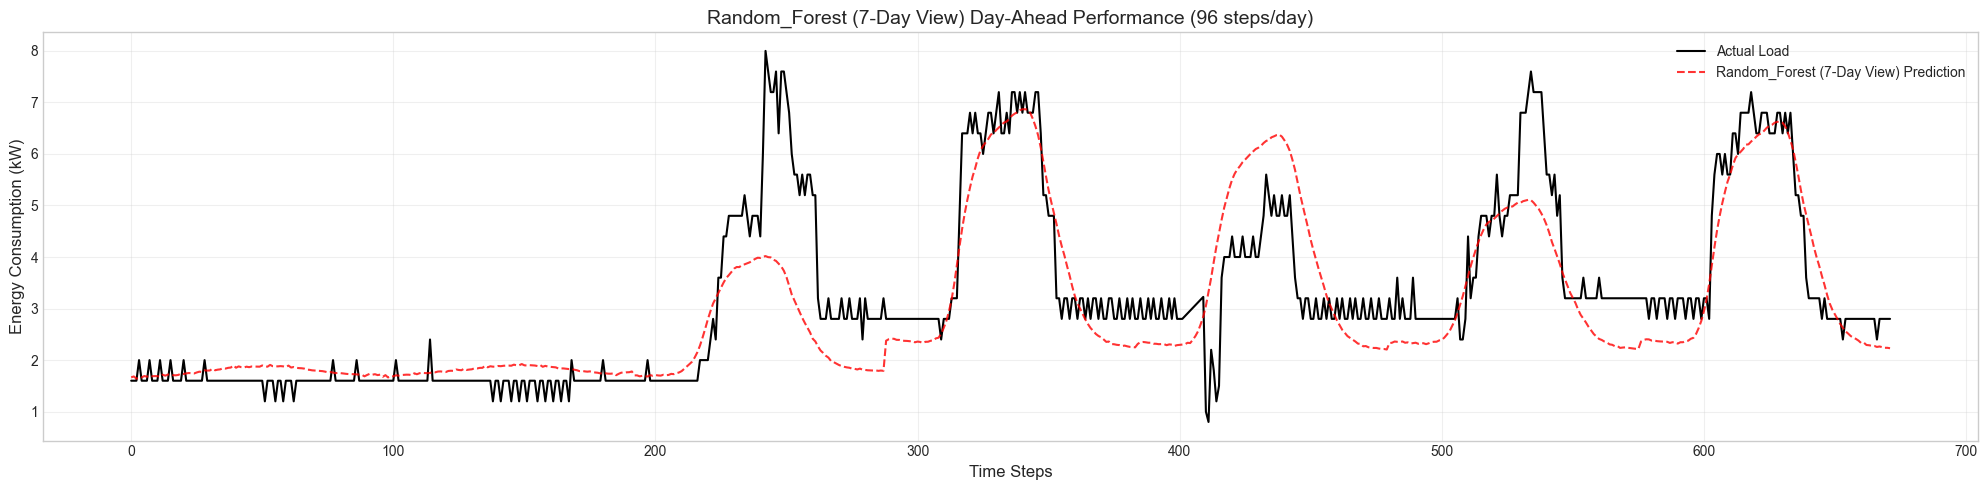

In [7]:
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

# Define exactly what is on your hard drive right now
tree_models = [
    {"folder": "XGBoost_MAE", "file": "xgboost_mae_model.joblib"},
    {"folder": "XGBoost_RMSE", "file": "xgboost_rmse_model.joblib"},
    {"folder": "Random_Forest", "file": "random_forest_model.joblib"}
]

# Loop, Load, Predict and Plot
for model_info in tree_models:
    folder_name = model_info["folder"]
    file_name = model_info["file"]
    
    # Build the exact path based on your screenshot
    model_save_path = f"../results/{config.ACTIVE_HORIZON}/{folder_name}/{file_name}"
    
    try:
        print(f"\nLoading {folder_name} from cache...")
        cached_model = joblib.load(model_save_path)
        
        # Generate Predictions using the correct TREE matrix!
        test_preds = cached_model.predict(X_test_tree) 
        
        # Inverse Scale back to kW
        orig_shape = test_preds.shape
        test_preds_unscaled = dl_scaler_targ.inverse_transform(test_preds.reshape(-1, 1)).reshape(orig_shape)
        
        # Note: We must also inverse scale y_test_tree (or use y_test since they align identically)
        y_test_unscaled = dl_scaler_targ.inverse_transform(y_test.reshape(-1, 1)).reshape(orig_shape)
        
        # Plot 7 Days
        plot_predictions(
            y_true=y_test_unscaled, 
            y_pred=test_preds_unscaled, 
            model_name=f"{folder_name} (7-Day View)", 
            horizon=horizon_val,
            num_steps=horizon_val * 7
        )
    except FileNotFoundError:
        print(f"Could not find cached model at {model_save_path}.")

### **Deep Learning Models:**


 Running: Power_LSTM_Standard_Capacity

 RUNNING POWER_LSTM_STANDARD_CAPACITY (15_min) | Horizon: 96
Cache found! Loading cached inferences from ../results/15_min/Power_LSTM_Standard_Capacity\predictions.npz
Power_LSTM_Standard_Capacity artifacts successfully saved to ../results/15_min/Power_LSTM_Standard_Capacity/
 Power_LSTM_Standard_Capacity added to leaderboard! (MASE: 0.800)


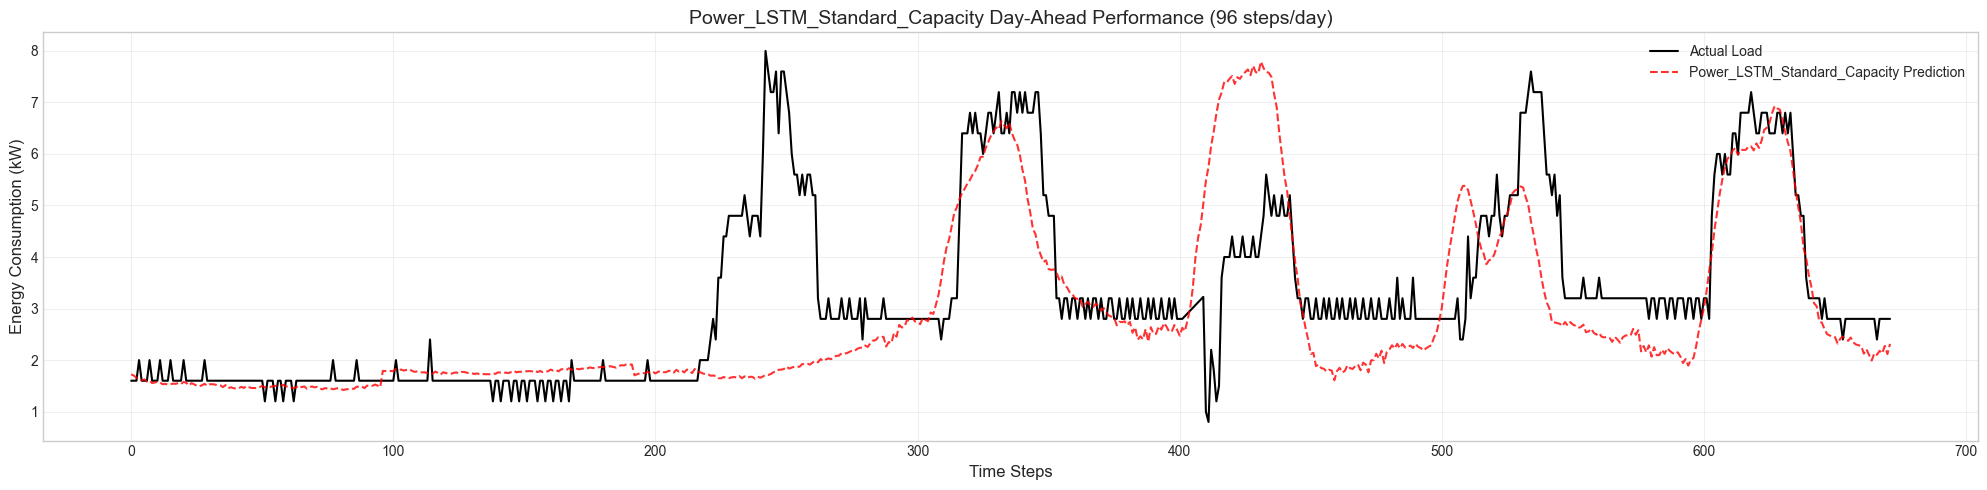


 Running: Power_LSTM_High_Capacity

 RUNNING POWER_LSTM_HIGH_CAPACITY (15_min) | Horizon: 96
Cache found! Loading cached inferences from ../results/15_min/Power_LSTM_High_Capacity\predictions.npz
Power_LSTM_High_Capacity artifacts successfully saved to ../results/15_min/Power_LSTM_High_Capacity/
 Power_LSTM_High_Capacity added to leaderboard! (MASE: 0.737)


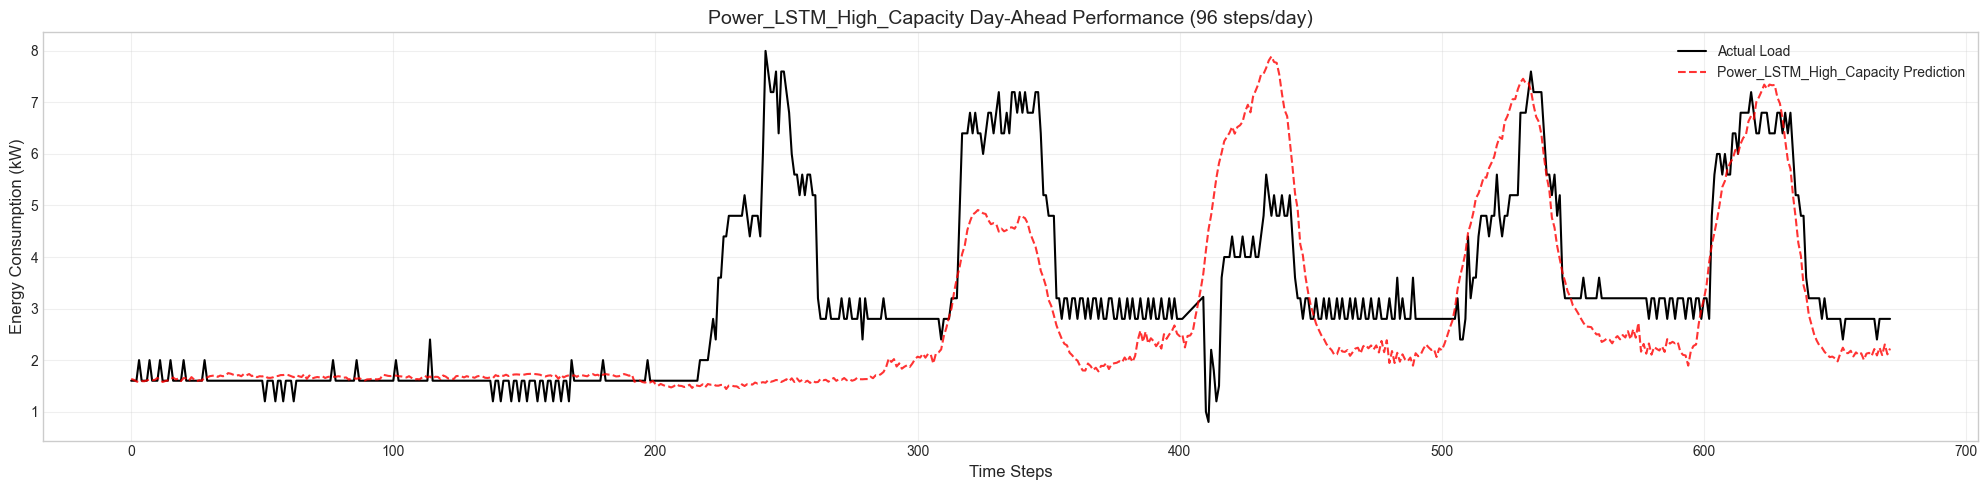

In [ ]:
# LSTM experiments
original_lstm_config = config.LSTM_CONFIG.copy()

lstm_experiments = [
    {
        "name": "Power_LSTM_Standard_Capacity", 
        "hidden_units": [64, 32], 
        "dropout": 0.2
    },
    {
        "name": "Power_LSTM_High_Capacity", 
        "hidden_units": [128, 64], 
        "dropout": 0.4  # Doubling capacity requires doubling regularization
    }
]

epochs = config.TRAINING_PARAMS["epochs"]
batch_size = config.TRAINING_PARAMS["batch_size"]
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for exp in lstm_experiments:
    exp_name = exp["name"]
    print(f"\n Running: {exp_name}")
    
    # Dynamically inject the experimental parameters into the config
    config.LSTM_CONFIG["hidden_units"] = exp["hidden_units"]
    config.LSTM_CONFIG["dropout"] = exp["dropout"]
    
    # Train or Load Model
    results = run_power_lstm(
        X_train=X_train_3d, y_train=y_train, 
        X_val=X_val_3d, y_val=y_val, 
        X_test=X_test_3d, y_test=y_test, 
        horizon_name=config.ACTIVE_HORIZON, 
        horizon=horizon_val, 
        epochs=epochs, 
        batch_size=batch_size, 
        random_state=config.RANDOM_SEED,
        experiment_name=exp_name,
        target_scaler=dl_scaler_targ,
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Get continuous 1D array for MASE denominator
    continuous_y_train = df_dl_scaled.iloc[:train_idx, dl_target_idx].values
    if dl_scaler_targ is not None:
        y_train_unscaled = dl_scaler_targ.inverse_transform(continuous_y_train.reshape(-1, 1)).flatten()
    else:
        y_train_unscaled = continuous_y_train.flatten()
        
    # Extract execution time
    old_time = results.get('execution_time', results.get('metrics', {}).get('Time (s)', 0.0))
        
    
    true_metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        execution_time=old_time, 
        horizon=horizon_val, 
        y_train=y_train_unscaled
    )
    
    results['metrics'] = true_metrics
    
    save_experiment_results(
        results_dict=results, 
        model_name=exp_name, 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results['y_test_real'], 
        horizon=horizon_val
    )
    
    # Append to leaderboard
    horizon_metrics.append(true_metrics)
    print(f" {exp_name} added to leaderboard! (MASE: {true_metrics['MASE']:.3f})")
    
    # Plot the 7-day trajectory to capture weekend dynamics
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        horizon=horizon_val,
        num_steps=horizon_val * 7 
    )

# Restore original config
config.LSTM_CONFIG = original_lstm_config


 RUNNING LSTM_WIDE_MSE (15_min) | Horizon: 96
Cache found! Loading cached inferences from ../results/15_min/LSTM_Wide_MSE\predictions.npz
LSTM_Wide_MSE artifacts successfully saved to ../results/15_min/LSTM_Wide_MSE/
 LSTM_Wide_MSE added to leaderboard! (MASE: 0.841)


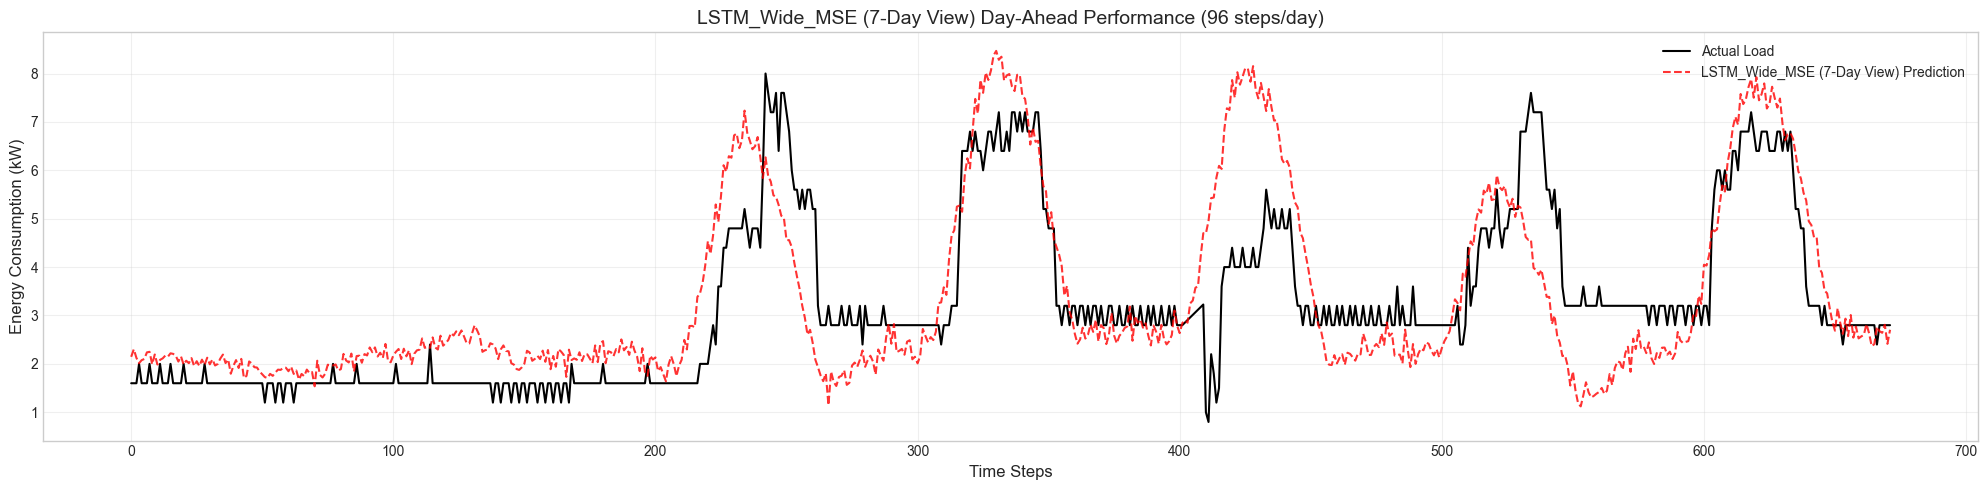

In [ ]:
# LSTM experiment
original_lstm_config = config.LSTM_CONFIG.copy()
config.LSTM_CONFIG["hidden_units"] = [128, 96] 
config.LSTM_CONFIG["loss"] = "mse"
config.LSTM_CONFIG["dropout"] = 0.2
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]
model_name = "LSTM_Wide_MSE"

# Train/Load the Model
results_lstm = run_power_lstm(
    X_train=X_train_3d, y_train=y_train, 
    X_val=X_val_3d, y_val=y_val, 
    X_test=X_test_3d, y_test=y_test,
    horizon_name=config.ACTIVE_HORIZON,
    horizon=horizon_val,
    epochs=config.TRAINING_PARAMS["epochs"], 
    batch_size=config.TRAINING_PARAMS["batch_size"],
    random_state=config.RANDOM_SEED,
    experiment_name=model_name,
    target_scaler=dl_scaler_targ,
    train_from_scratch=TRAIN_FROM_SCRATCH
)

# Get continuous 1D array for MASE denominator
continuous_y_train = df_dl_scaled.iloc[:train_idx, dl_target_idx].values
if dl_scaler_targ is not None:
    y_train_unscaled = dl_scaler_targ.inverse_transform(continuous_y_train.reshape(-1, 1)).flatten()
else:
    y_train_unscaled = continuous_y_train.flatten()

# Extract execution time
old_time = results_lstm.get('execution_time', results_lstm.get('metrics', {}).get('Time (s)', 0.0))

true_metrics = calculate_metrics(
    y_true=results_lstm['y_test_real'], 
    y_pred=results_lstm['predictions'], 
    model_name=model_name, 
    execution_time=old_time, 
    horizon=horizon_val, 
    y_train=y_train_unscaled
)

results_lstm['metrics'] = true_metrics

# Save Artifacts
save_experiment_results(
    results_dict=results_lstm, 
    model_name=model_name, 
    horizon_name=config.ACTIVE_HORIZON, 
    y_test=results_lstm['y_test_real'], 
    horizon=horizon_val
)

# Append to Leaderboard
horizon_metrics.append(true_metrics)
print(f" {model_name} added to leaderboard! (MASE: {true_metrics['MASE']:.3f})")

# Plot predictions
plot_predictions(
    y_true=results_lstm['y_test_real'], 
    y_pred=results_lstm['predictions'], 
    model_name=f"{model_name} (7-Day View)", 
    horizon=horizon_val,
    num_steps=horizon_val * 7
)

# Restore config
config.LSTM_CONFIG = original_lstm_config

Generating 192-step (2-Day) matrices for deep context testing
1-Day Test Targets (y): 10454
2-Day Test Targets (y): 10358 (Shorter due to warmup)

Running: Vanilla_Transformer_1Day_Context (Sequence: 96)

RUNNING VANILLA_TRANSFORMER_1DAY_CONTEXT (15_min) | Horizon: 96
Loading cached inferences from ../results/15_min/Vanilla_Transformer_1Day_Context\predictions.npz
Vanilla_Transformer_1Day_Context artifacts successfully saved to ../results/15_min/Vanilla_Transformer_1Day_Context/
Vanilla_Transformer_1Day_Context added to leaderboard! (MASE: 0.797)


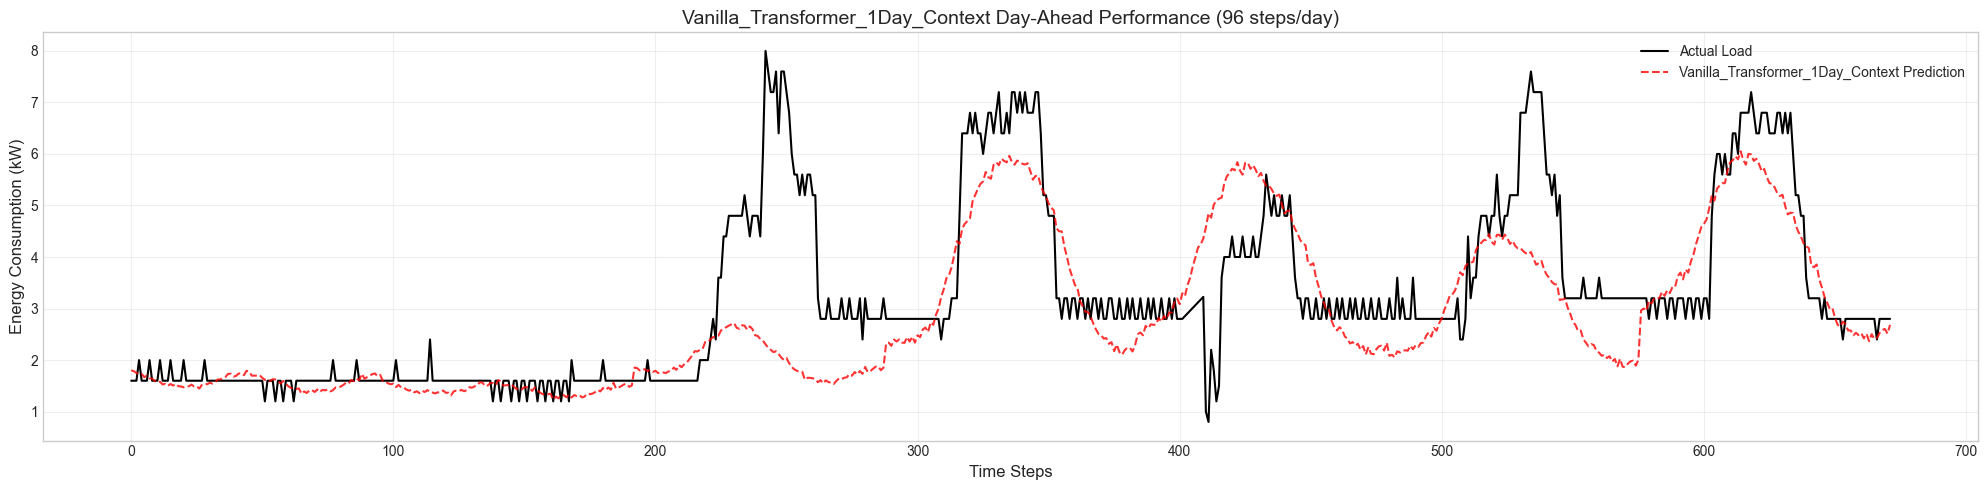


Running: Vanilla_Transformer_2Day_Context (Sequence: 192)

RUNNING VANILLA_TRANSFORMER_2DAY_CONTEXT (15_min) | Horizon: 96
Loading cached inferences from ../results/15_min/Vanilla_Transformer_2Day_Context\predictions.npz
Vanilla_Transformer_2Day_Context artifacts successfully saved to ../results/15_min/Vanilla_Transformer_2Day_Context/
Vanilla_Transformer_2Day_Context added to leaderboard! (MASE: 1.110)


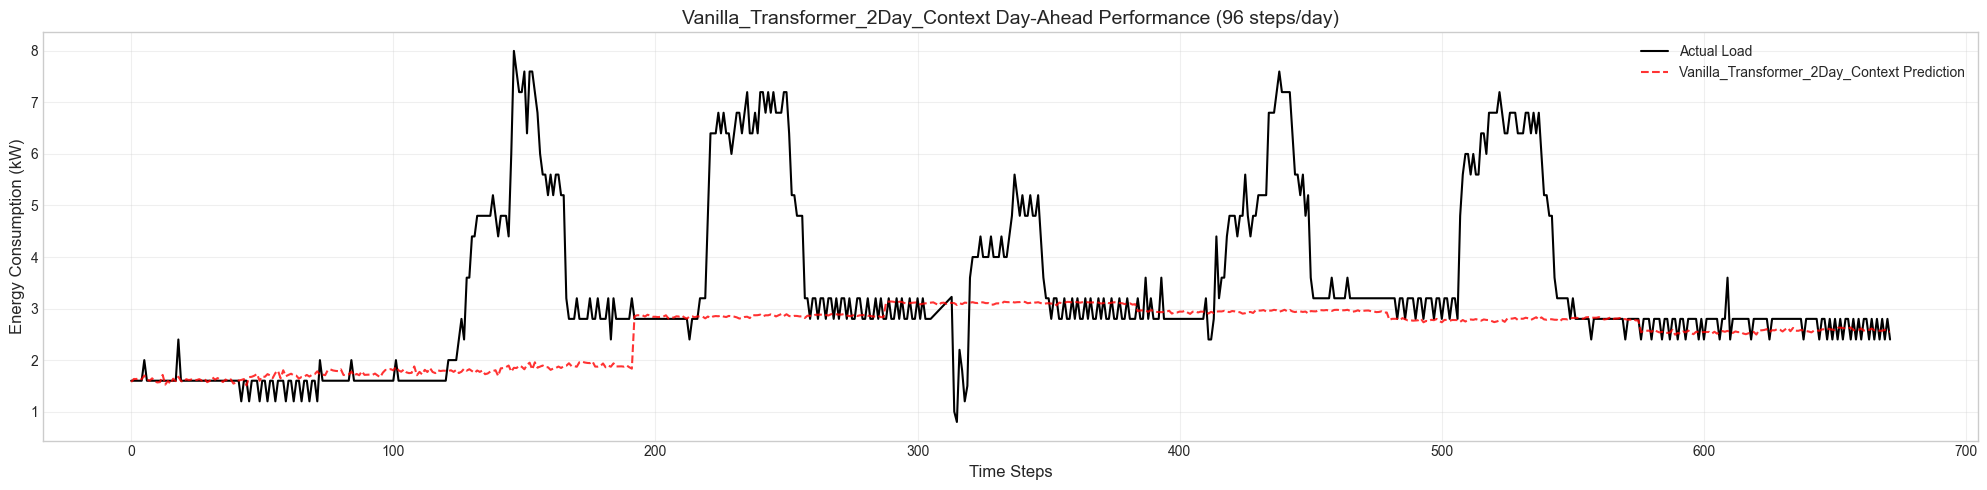

In [ ]:
# Vanila Transformer experiments
print("Generating 192-step (2-Day) matrices for deep context testing")
SEQ_LENGTH_192 = 192
HORIZON_STEPS = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

# Using the already scaled dataframe (df_dl_scaled) to prevent scaler leakage
X_train_192, y_train_192 = create_multivariate_sequences(df_dl_scaled.iloc[:train_idx].values, dl_target_idx, SEQ_LENGTH_192, HORIZON_STEPS)
X_val_192, y_val_192     = create_multivariate_sequences(df_dl_scaled.iloc[train_idx:val_idx].values, dl_target_idx, SEQ_LENGTH_192, HORIZON_STEPS)
X_test_192, y_test_192   = create_multivariate_sequences(df_dl_scaled.iloc[val_idx:].values, dl_target_idx, SEQ_LENGTH_192, HORIZON_STEPS)

print(f"1-Day Test Targets (y): {y_test.shape[0]}")
print(f"2-Day Test Targets (y): {y_test_192.shape[0]} (Shorter due to warmup)")

transformer_experiments = [
    {
        "name": "Vanilla_Transformer_1Day_Context",
        "X_train": X_train_3d, "y_train": y_train,
        "X_val": X_val_3d, "y_val": y_val,
        "X_test": X_test_3d, "y_test": y_test,
        "seq_len": 96
    },
    {
        "name": "Vanilla_Transformer_2Day_Context",
        "X_train": X_train_192, "y_train": y_train_192,
        "X_val": X_val_192, "y_val": y_val_192,
        "X_test": X_test_192, "y_test": y_test_192,
        "seq_len": 192
    }
]

epochs = config.TRAINING_PARAMS["epochs"]
batch_size = config.TRAINING_PARAMS["batch_size"]
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for exp in transformer_experiments:
    exp_name = exp["name"]
    print(f"\nRunning: {exp_name} (Sequence: {exp['seq_len']})")
    
    # Train or Load Model
    results = run_vanilla_transformer(
        X_train=exp["X_train"], y_train=exp["y_train"], 
        X_val=exp["X_val"], y_val=exp["y_val"], 
        X_test=exp["X_test"], y_test=exp["y_test"], 
        horizon_name=config.ACTIVE_HORIZON, 
        horizon=horizon_val, 
        epochs=epochs, 
        batch_size=batch_size, 
        random_state=config.RANDOM_SEED, 
        experiment_name=exp_name,
        target_scaler=dl_scaler_targ,
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Get continuous 1D array for MASE denominator
    continuous_y_train = df_dl_scaled.iloc[:train_idx, dl_target_idx].values
    if dl_scaler_targ is not None:
        y_train_unscaled = dl_scaler_targ.inverse_transform(continuous_y_train.reshape(-1, 1)).flatten()
    else:
        y_train_unscaled = continuous_y_train.flatten()
        
    # Extract execution time
    old_time = results.get('execution_time', results.get('metrics', {}).get('Time (s)', 0.0))
    
    true_metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        execution_time=old_time, 
        horizon=horizon_val, 
        y_train=y_train_unscaled
    )
    
    results['metrics'] = true_metrics
    
    # Save Artifacts
    save_experiment_results(
        results_dict=results, 
        model_name=exp_name, 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results['y_test_real'], 
        horizon=horizon_val
    )
    
    # Append to leaderboard
    horizon_metrics.append(true_metrics)
    print(f"{exp_name} added to leaderboard! (MASE: {true_metrics['MASE']:.3f})")
    
    # Plot the 7-day trajectory
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        horizon=horizon_val,
        num_steps=horizon_val * 7 
    )


Running: PatchTST_1Day_2Hr_Patches (Sequence: 96 | Patch: 8)

RUNNING PATCHTST_1DAY_2HR_PATCHES (15_min) | Horizon: 96
Loading cached inferences from ../results/15_min/PatchTST_1Day_2Hr_Patches\predictions.npz
PatchTST_1Day_2Hr_Patches artifacts successfully saved to ../results/15_min/PatchTST_1Day_2Hr_Patches/
PatchTST_1Day_2Hr_Patches added to leaderboard! (MASE: 0.789)


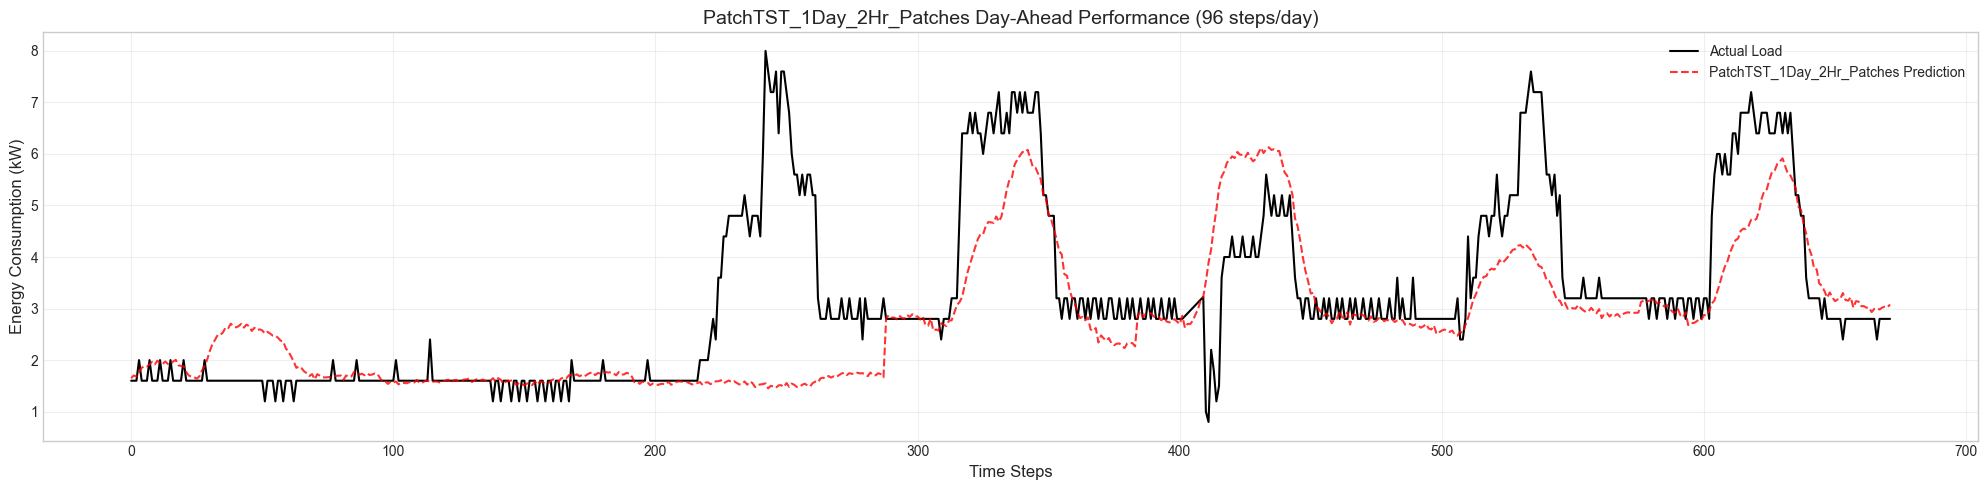


Running: PatchTST_2Day_2Hr_Patches (Sequence: 192 | Patch: 8)

RUNNING PATCHTST_2DAY_2HR_PATCHES (15_min) | Horizon: 96
Loading cached inferences from ../results/15_min/PatchTST_2Day_2Hr_Patches\predictions.npz
PatchTST_2Day_2Hr_Patches artifacts successfully saved to ../results/15_min/PatchTST_2Day_2Hr_Patches/
PatchTST_2Day_2Hr_Patches added to leaderboard! (MASE: 0.821)


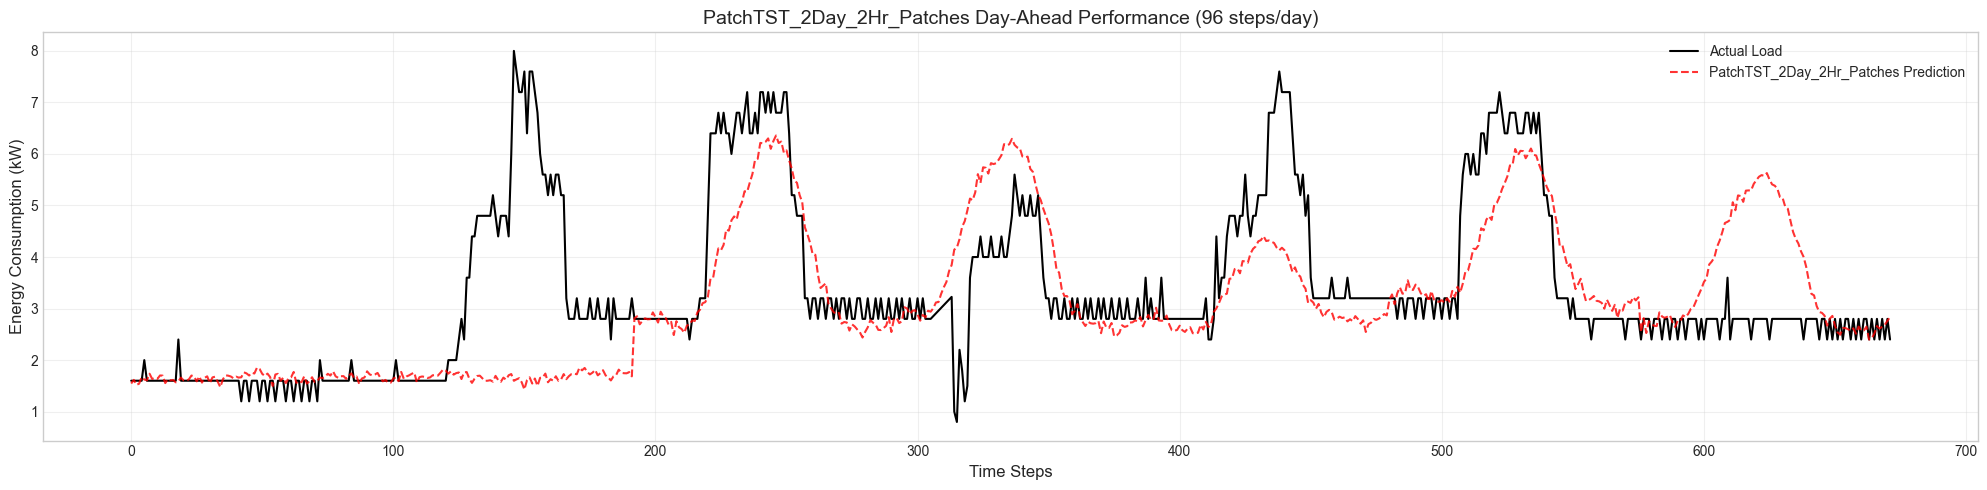


Running: PatchTST_2Day_4Hr_Patches (Sequence: 192 | Patch: 16)

RUNNING PATCHTST_2DAY_4HR_PATCHES (15_min) | Horizon: 96
Loading cached inferences from ../results/15_min/PatchTST_2Day_4Hr_Patches\predictions.npz
PatchTST_2Day_4Hr_Patches artifacts successfully saved to ../results/15_min/PatchTST_2Day_4Hr_Patches/
PatchTST_2Day_4Hr_Patches added to leaderboard! (MASE: 0.800)


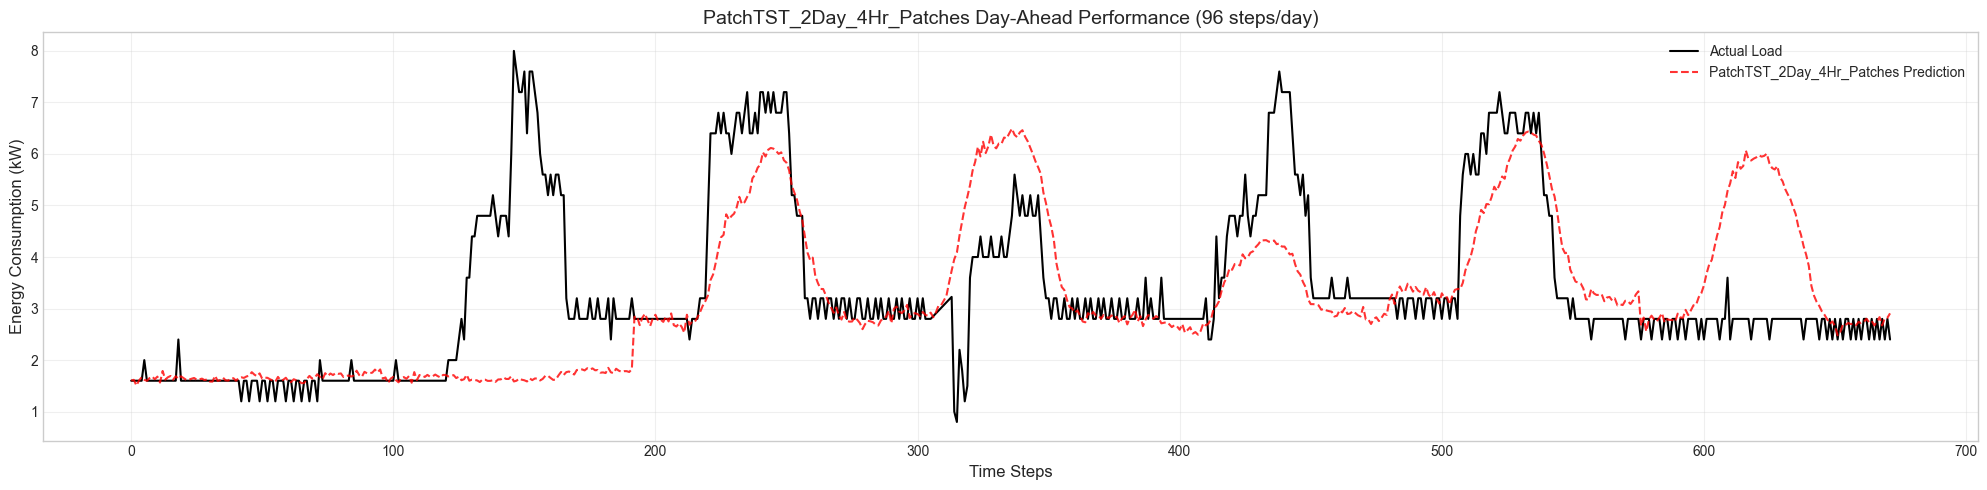

In [ ]:
# PatchTST experiments

patch_experiments = [
    {
        "name": "PatchTST_1Day_2Hr_Patches",
        "X_train": X_train_3d, "y_train": y_train,
        "X_val": X_val_3d, "y_val": y_val,
        "X_test": X_test_3d, "y_test": y_test,
        "seq_len": 96, "patch_len": 8, "stride": 8
    },
    {
        "name": "PatchTST_2Day_2Hr_Patches",
        "X_train": X_train_192, "y_train": y_train_192,
        "X_val": X_val_192, "y_val": y_val_192,
        "X_test": X_test_192, "y_test": y_test_192,
        "seq_len": 192, "patch_len": 8, "stride": 8
    },
    {
        "name": "PatchTST_2Day_4Hr_Patches",
        "X_train": X_train_192, "y_train": y_train_192,
        "X_val": X_val_192, "y_val": y_val_192,
        "X_test": X_test_192, "y_test": y_test_192,
        "seq_len": 192, "patch_len": 16, "stride": 16
    }
]

for exp in patch_experiments:
    exp_name = exp["name"]
    print(f"\nRunning: {exp_name} (Sequence: {exp['seq_len']} | Patch: {exp['patch_len']})")
    
    # Train or Load Model
    results = run_keras_patchtst(
        X_train=exp["X_train"], y_train=exp["y_train"],
        X_val=exp["X_val"], y_val=exp["y_val"],
        X_test=exp["X_test"], y_test=exp["y_test"],
        horizon_name=config.ACTIVE_HORIZON,
        horizon=horizon_val,
        epochs=epochs,
        batch_size=batch_size,
        patch_len=exp["patch_len"],
        stride=exp["stride"],
        target_idx=dl_target_idx,
        random_state=config.RANDOM_SEED,
        experiment_name=exp_name,
        target_scaler=dl_scaler_targ,
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Get continuous 1D array for MASE denominator
    continuous_y_train = df_dl_scaled.iloc[:train_idx, dl_target_idx].values
    if dl_scaler_targ is not None:
        y_train_unscaled = dl_scaler_targ.inverse_transform(continuous_y_train.reshape(-1, 1)).flatten()
    else:
        y_train_unscaled = continuous_y_train.flatten()
    
    # Extract execution time
    old_time = results.get('execution_time', results.get('metrics', {}).get('Time (s)', 0.0))
    
    true_metrics = calculate_metrics(
        y_true=results['y_test_real'],
        y_pred=results['predictions'],
        model_name=exp_name,
        execution_time=old_time,
        horizon=horizon_val,
        y_train=y_train_unscaled
    )
    
    results['metrics'] = true_metrics
    
    # Save Artifacts
    save_experiment_results(
        results_dict=results,
        model_name=exp_name,
        horizon_name=config.ACTIVE_HORIZON,
        y_test=results['y_test_real'],
        horizon=horizon_val
    )
    
    # Append to leaderboard
    horizon_metrics.append(true_metrics)
    print(f"{exp_name} added to leaderboard! (MASE: {true_metrics['MASE']:.3f})")
    
    # Plot the 7-day trajectory
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp_name, 
        horizon=horizon_val,
        num_steps=horizon_val * 7 
    )

### **Foundation Models (Chronos and Chronos2)**


 RUNNING CHRONOS ZERO-SHOT (amazon_chronos-t5-small) | Horizon: 96
Cache found! Loading cached inferences from ../results/15_min/amazon_chronos-t5-small\predictions.npz


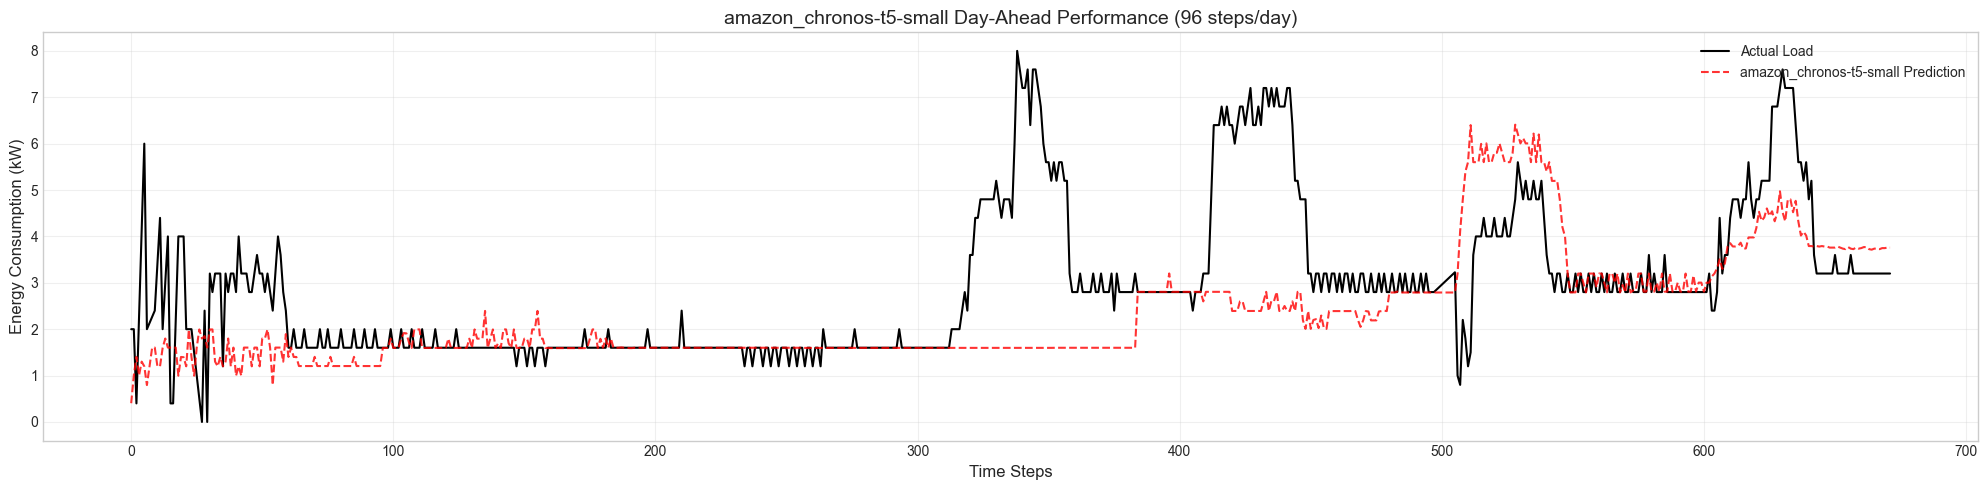

amazon_chronos-t5-small artifacts successfully saved to ../results/15_min/amazon_chronos-t5-small/

 RUNNING CHRONOS ZERO-SHOT (amazon_chronos-t5-base) | Horizon: 96
Cache found! Loading cached inferences from ../results/15_min/amazon_chronos-t5-base\predictions.npz


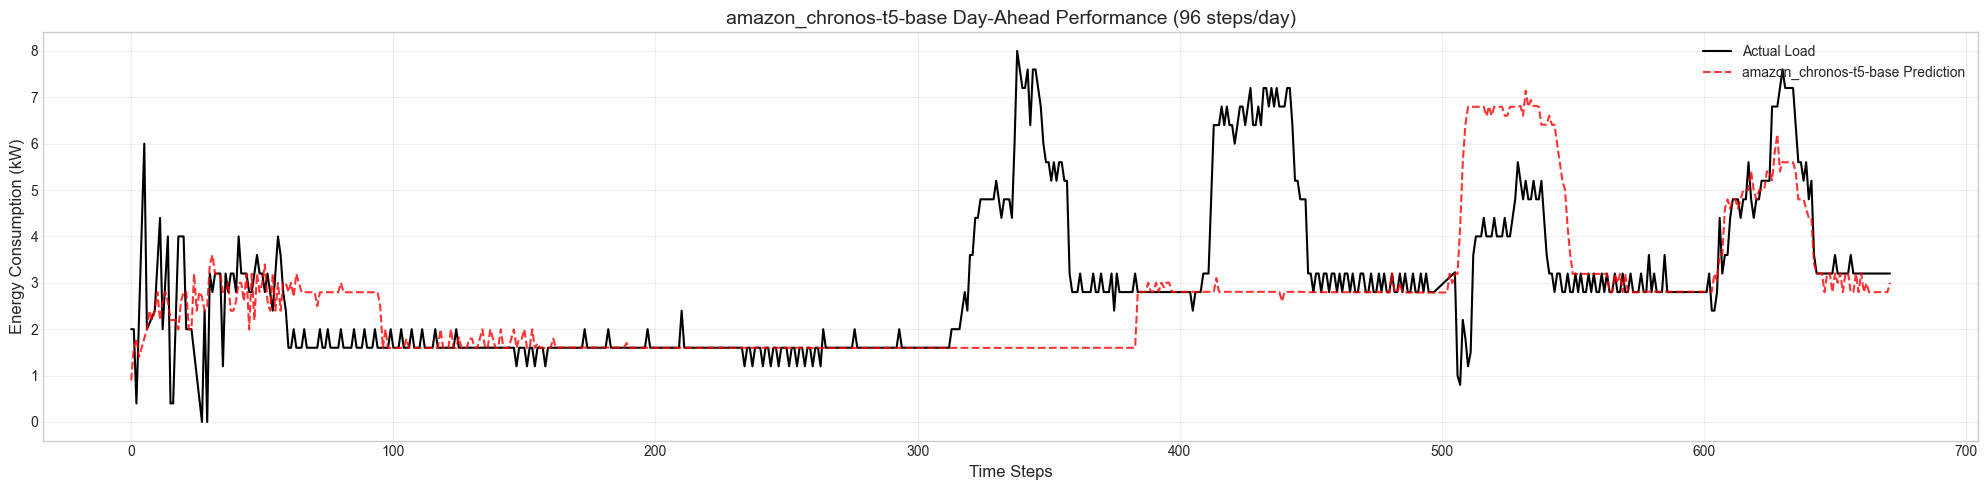

amazon_chronos-t5-base artifacts successfully saved to ../results/15_min/amazon_chronos-t5-base/

 RUNNING CHRONOS ZERO-SHOT (amazon_chronos-t5-large) | Horizon: 96
Cache found! Loading cached inferences from ../results/15_min/amazon_chronos-t5-large\predictions.npz


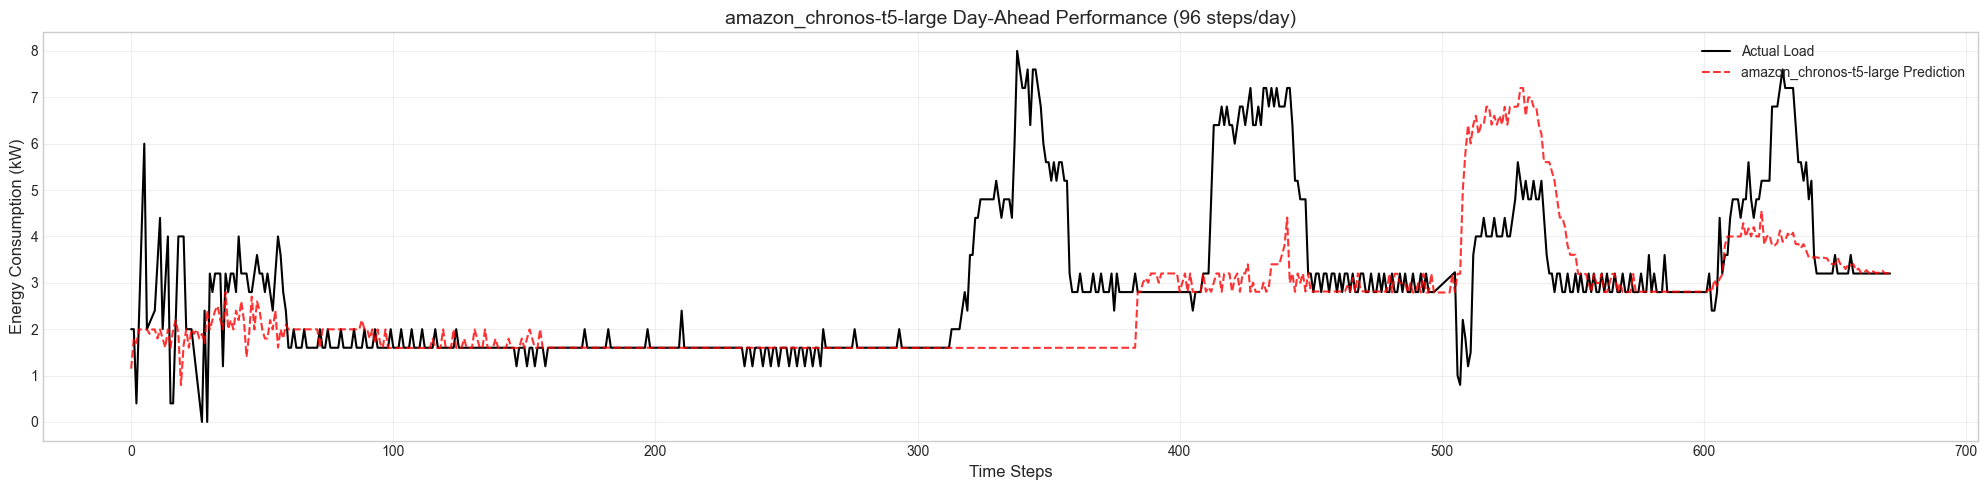

amazon_chronos-t5-large artifacts successfully saved to ../results/15_min/amazon_chronos-t5-large/


In [12]:
chronos_models = [
    {"name": "amazon/chronos-t5-small", "batch_size": 32},
    {"name": "amazon/chronos-t5-base",  "batch_size": 16},
    {"name": config.CHRONOS_CONFIG["model_name"], "batch_size": config.CHRONOS_CONFIG["batch_size"]} 
]
horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for model_config in chronos_models:
    model_name = model_config["name"]
    batch_size = model_config["batch_size"]
    
    results_chronos = run_chronos_univariate(
        df=df_master, # Unscaled dataframe
        target_col=TARGET_COL,
        horizon_name=config.ACTIVE_HORIZON,
        model_name=model_name, 
        batch_size=batch_size, 
        context_length=512, # 5.3 days of context
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Save artifacts using the existing pipeline
    save_experiment_results(
        results_dict=results_chronos, 
        model_name=results_chronos["model"], 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results_chronos['y_test_real'], 
        horizon=horizon_val
    )
    
    horizon_metrics.append(results_chronos["metrics"])

In [13]:
# Explicitly Map the Features
weather_cols = ["temperature_v1", "relative_humidity_v1", "wind_speed_v1", "clouds_v1"]
market_cols = ["energy_generation", "smp"]

time_cols = [
    "hour_sin", "hour_cos", "day_sin", "day_cos", "month_sin", "month_cos", 
    "is_holiday", "is_weekend", "is_non_working_day", "energy_flow_quarter"
]

lag_cols = [
    "energy_consumption_lag_1w", "energy_generation_lag_1w", 
    "smp_lag_1w", "temperature_v1_lag_1w"
]

# Create the Datasets for Chronos2_Multivariate experiments
df_oracle = df_master.copy()
df_degraded = df_master.copy()

total_rows = len(df_master)
train_val_idx = int(total_rows * (config.TRAIN_SPLIT + config.VAL_SPLIT))

np.random.seed(config.RANDOM_SEED)

# Apply Realistic Forecast Error (Noise) to the Test Horizon
for col in weather_cols + market_cols:
    if col == "temperature_v1":
        noise = np.random.normal(0.0, 2.0, size=(total_rows - train_val_idx)) # +/- 2 degrees
    elif col == "relative_humidity_v1" or col == "clouds_v1":
        noise = np.random.normal(0.0, 5.0, size=(total_rows - train_val_idx)) # +/- 5%
    elif col == "wind_speed_v1":
        noise = np.random.normal(0.0, 1.5, size=(total_rows - train_val_idx)) # +/- 1.5 m/s
    elif col == "energy_generation":
        noise = np.random.normal(0.0, df_master[col].std() * 0.1, size=(total_rows - train_val_idx)) # 10% error
    elif col == "smp":
        noise = np.random.normal(0.0, df_master[col].std() * 0.1, size=(total_rows - train_val_idx)) # 10% error
        
    df_degraded.iloc[train_val_idx:, df_degraded.columns.get_loc(col)] += noise


 RUNNING CHRONOS2_MULTIVARIATE_ORACLE | Horizon: 96
Loading cached inferences from ../results/15_min/Chronos2_Multivariate_Oracle\predictions.npz
Chronos2_Multivariate_Oracle artifacts successfully saved to ../results/15_min/Chronos2_Multivariate_Oracle/
Chronos2_Multivariate_Oracle added to leaderboard! (MASE: 0.697)


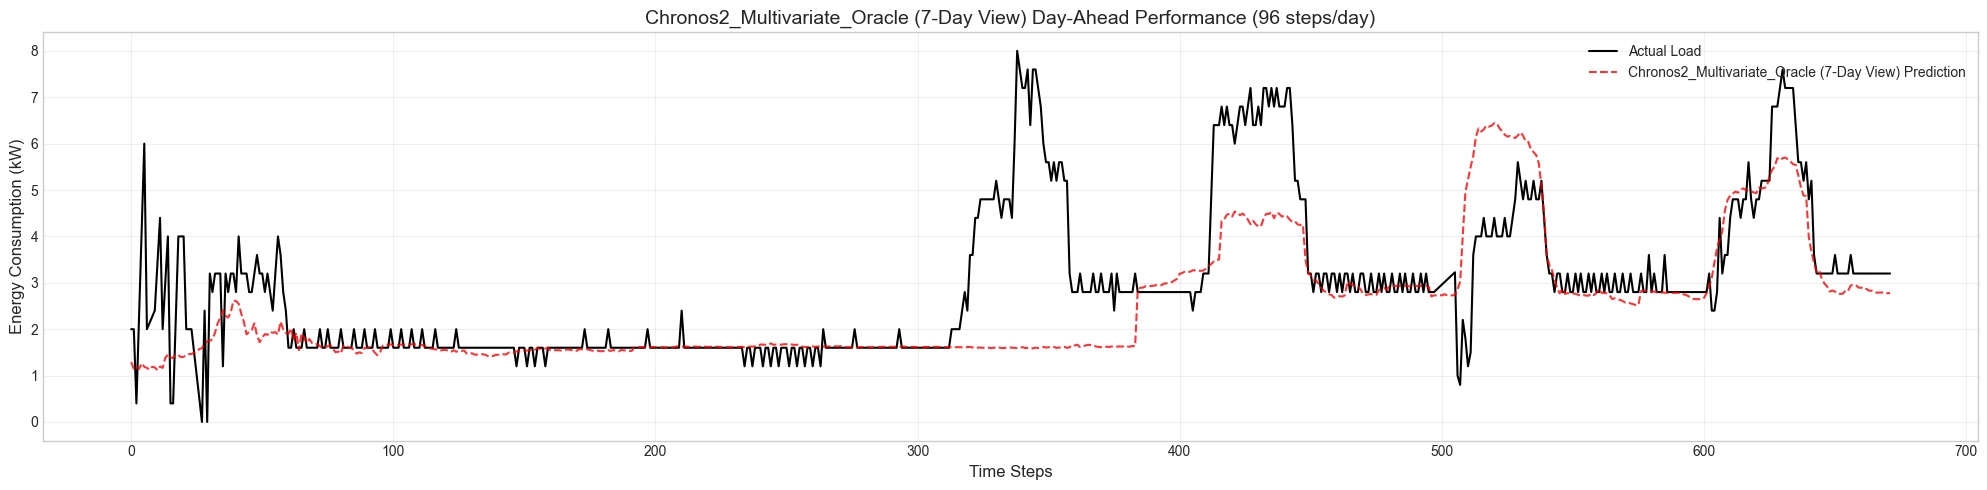


 RUNNING CHRONOS2_MULTIVARIATE_REALISTIC | Horizon: 96
Loading cached inferences from ../results/15_min/Chronos2_Multivariate_Realistic\predictions.npz
Chronos2_Multivariate_Realistic artifacts successfully saved to ../results/15_min/Chronos2_Multivariate_Realistic/
Chronos2_Multivariate_Realistic added to leaderboard! (MASE: 0.704)


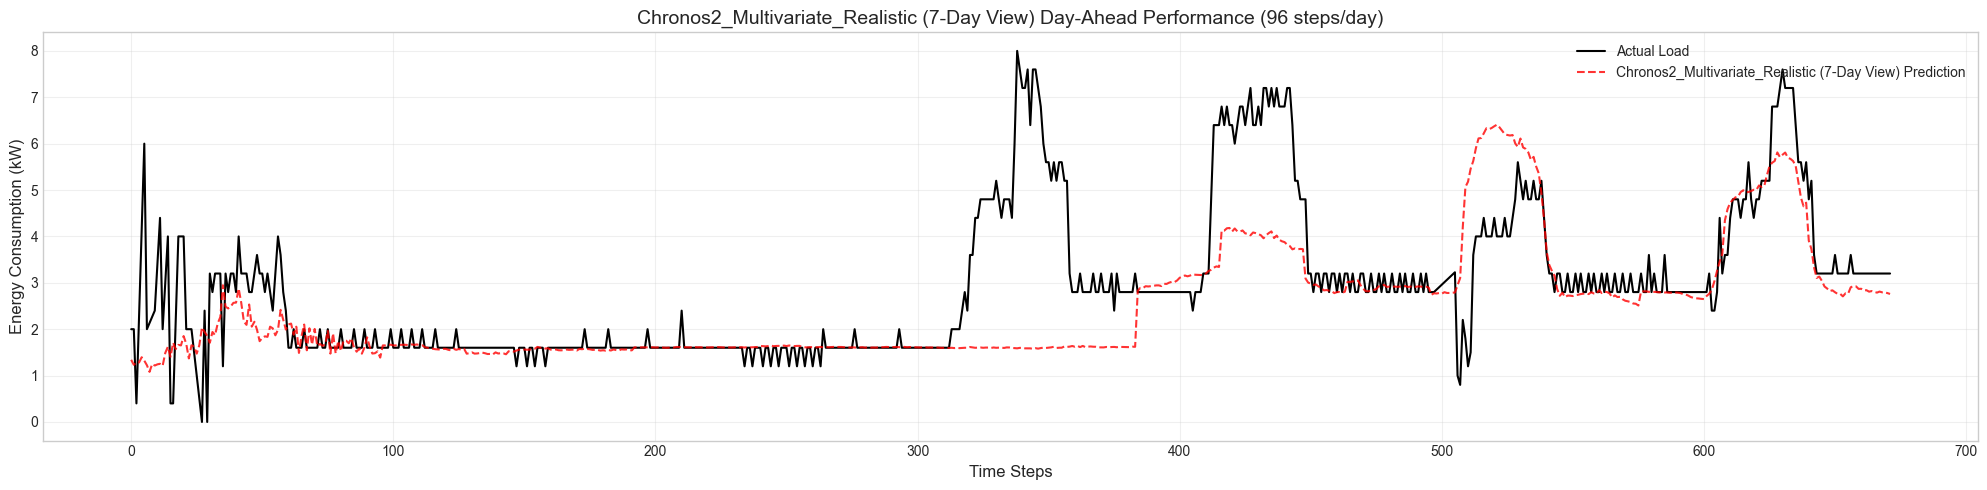


 RUNNING CHRONOS2_MULTIVARIATE_BLIND | Horizon: 96
Loading cached inferences from ../results/15_min/Chronos2_Multivariate_Blind\predictions.npz
Chronos2_Multivariate_Blind artifacts successfully saved to ../results/15_min/Chronos2_Multivariate_Blind/
Chronos2_Multivariate_Blind added to leaderboard! (MASE: 0.690)


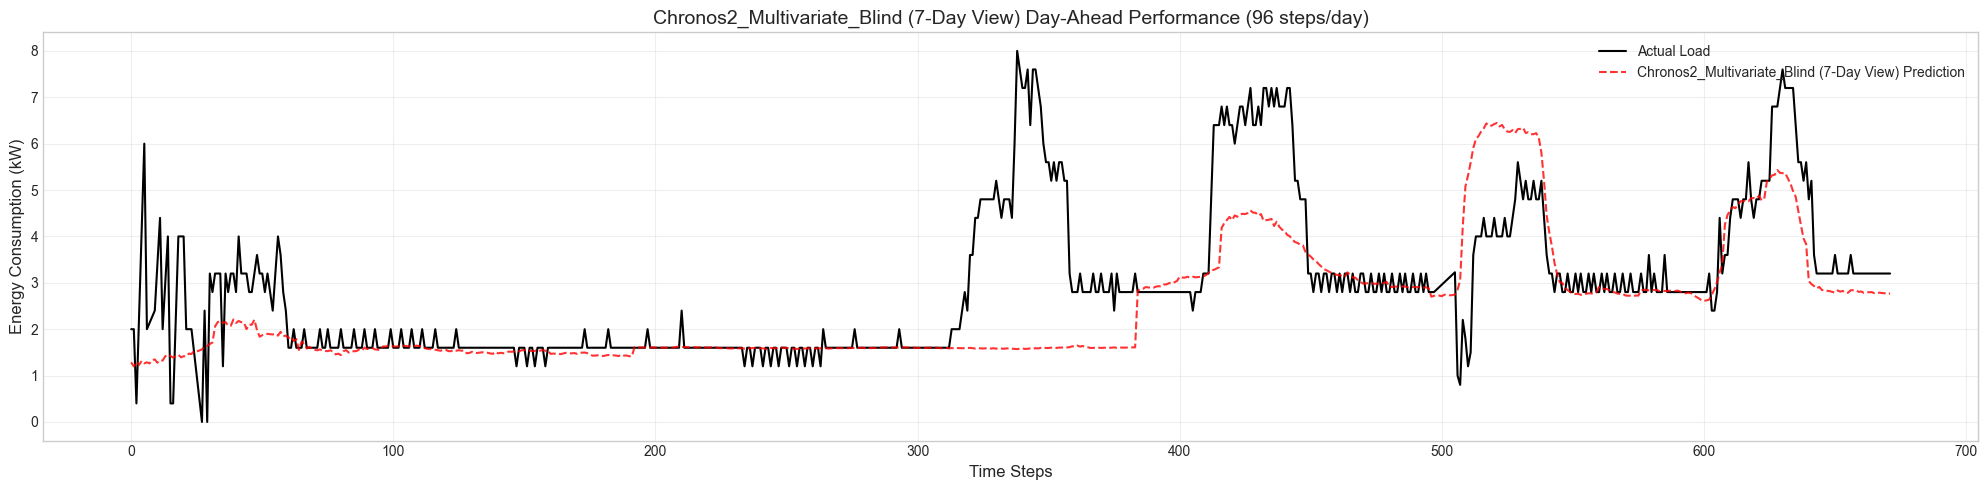

In [14]:
# Chronos2 Multivariate experiments
# The covariates we explicitly pass into the future context
base_deterministic_cols = time_cols + lag_cols
uncertain_forecast_cols = weather_cols + market_cols

# Define the 3 Experiments
chronos2_experiments = [
    {
        "exp_name": "Chronos2_Multivariate_Oracle",
        "df": df_oracle,
        "covariates": base_deterministic_cols + uncertain_forecast_cols 
    },
    {
        "exp_name": "Chronos2_Multivariate_Realistic",
        "df": df_degraded,
        "covariates": base_deterministic_cols + uncertain_forecast_cols
    },
    {
        "exp_name": "Chronos2_Multivariate_Blind",
        "df": df_master,
        "covariates": base_deterministic_cols 
    }
]

horizon_val = config.HORIZON_STEPS[config.ACTIVE_HORIZON]

for exp in chronos2_experiments:
    results = run_chronos2_multivariate_v2(
        df=exp["df"],
        deterministic_covariates=exp["covariates"],
        experiment_name=exp["exp_name"],
        target_col=TARGET_COL,
        horizon_name=config.ACTIVE_HORIZON,
        model_name=config.CHRONOS_2_CONFIG["model_name"],
        batch_size=config.CHRONOS_2_CONFIG["batch_size"],
        context_length=config.CHRONOS_2_CONFIG["context_length"],
        train_from_scratch=TRAIN_FROM_SCRATCH
    )
    
    # Extract baseline training values for MASE calculation
    y_train_raw = df_master[TARGET_COL].values[:int(len(df_master) * (config.TRAIN_SPLIT + config.VAL_SPLIT))]
    
    # Calculate metrics
    metrics = calculate_metrics(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=exp['exp_name'], 
        execution_time=results['execution_time'], 
        horizon=horizon_val, 
        y_train=y_train_raw
    )
    results['metrics'] = metrics
    
    # Save standard experiment metadata metrics
    save_experiment_results(
        results_dict=results, 
        model_name=exp['exp_name'], 
        horizon_name=config.ACTIVE_HORIZON, 
        y_test=results['y_test_real'], 
        horizon=horizon_val
    )
    
    horizon_metrics.append(metrics)
    print(f"{exp['exp_name']} added to leaderboard! (MASE: {metrics['MASE']:.3f})")
    
    # Plot performance trajectory
    plot_predictions(
        y_true=results['y_test_real'], 
        y_pred=results['predictions'], 
        model_name=f"{exp['exp_name']} (7-Day View)", 
        horizon=horizon_val,
        num_steps=horizon_val * 7 
    )

**Experiment 1:** The Oracle Model (Perfect Foresight)
What we are doing: We are passing the df_oracle dataset, which contains the 100% accurate, actual recorded weather and market data for the future horizon.

Why we are doing it: This establishes the Absolute Mathematical Ceiling of your foundation model. You are asking: "If a psychic gave me a flawless weather and market forecast, how accurate could this model possibly be?" This proves the model's capacity to learn thermodynamics and market behavior under perfect conditions.

**Experiment 2:** The Realistic Model (Degraded Forecast)
What we are doing: We are passing the df_degraded dataset. We injected realistic Gaussian noise into the test horizon (e.g., simulating a meteorologist being off by 2°C or 5% humidity, and a grid forecast being off by 10%).

Why we are doing it: This simulates Real-World Deployment. It answers a critical engineering question: Is the foundation model robust to noisy data? If a minor error in the weather forecast causes the LLM's predictions to completely collapse, the model is too fragile for real-world grid operations.

**Experiment 3:** The Blind Model (Zero Exogenous Data)
What we are doing: We are completely hiding the weather and market data from the future context, providing only deterministic time features (like the hour of the day and 1-week lags).

Diagnostic analysis of the top-performing model reveals a highly leptokurtic error distribution centered near zero, indicating high confidence and accuracy. While the Shapiro-Wilk test confirmed the errors are non-normal—justifying the use of the Diebold-Mariano test—the ACF plots revealed a strong cyclical correlation at lag 96. This proves that while Chronos is a powerful foundation model, its 'Blind' multivariate configuration still leaves 24-hour seasonal residuals on the table, highlighting the necessity of feeding it autoregressive lag features in the realistic and oracle scenarios.

### **Statistical Significance**

# Final Evaluation & Statistical Diagnostics

This final execution block consolidates the complete evaluation pipeline for this temporal horizon. It moves beyond standard point-forecast metrics to rigorously test the models for statistical significance, physical explainability, and econometric stability. 

The pipeline executes the following five evaluations:

### 1. Global Performance Metrics & Hourly Error Heatmap
* **The Leaderboard:** Compiles the final evaluation metrics (MASE, RMSE, MAE, sMAPE) and sorts the models to identify the absolute champion.
* **The Heatmap:** Generates a cross-model chronological heatmap to visually identify specific hours or days where models systematically succeed or fail.

### 2. Feature Importance (Explainability)
* **The Goal:** Opens the "black box" of the classical Machine Learning algorithms (XGBoost & Random Forest).
* **The Output:** Bar charts extracting the top 15 features, proving whether the models rely more heavily on autoregressive momentum (lags), cyclical human behavior (calendar features), or exogenous weather data.

### 3. Probabilistic Forecasts (Uncertainty Bounds)
* **The Goal:** To evaluate the champion models' capacity for operational risk management.
* **The Output:** Visualizes the median prediction (P50) alongside the 10th and 90th percentile bounds (an 80% confidence interval). This demonstrates how the model dynamically widens its uncertainty during highly volatile daytime grid operations.

### 4. Residual Diagnostics (Econometric "White-Noise" Testing)
* **The Goal:** A perfect forecasting model should leave behind errors that are completely random (white noise). This phase tests the champion model's errors for uncaptured patterns.
* **The Output:** * **Shapiro-Wilk Test & Distribution:** Tests the residuals for normality and leptokurtosis (heavy tails).
    * **ACF & PACF Plots:** The "Memory" test. Identifies whether the errors are correlated with each other, exposing any uncaptured deterministic seasonality (e.g., a lingering 24-hour diurnal cycle).

### 5. Diebold-Mariano Statistical Significance Shootout
* **The Goal:** To prove that the champion model's superiority is mathematically definitive, not a product of random chance.
* **The Output:** A pairwise statistical matrix comparing the champion model against every other baseline and contender ($a = 0.05$).


 EVALUATION METRICS TABLE FOR (15_min)
Leaderboard successfully saved to ../results/15_min/leaderboard.csv


,Model,RMSE,MAE,R2,CVRMSE,NMBE,sMAPE,MASE,Time (s)
0,Chronos2_Multivariate_Blind,1.1130,0.6435,0.6984,0.4028,-0.0055,22.2740,0.6901,278.61 s
1,Chronos2_Multivariate_Oracle,1.1346,0.6504,0.6865,0.4106,-0.0096,22.3981,0.6975,282.17 s
2,Chronos2_Multivariate_Realistic,1.1440,0.6563,0.6813,0.4140,-0.0057,22.5726,0.7038,281.03 s
3,Power_LSTM_High_Capacity,1.1370,0.7354,0.6872,0.4103,0.0471,27.1229,0.7368,7.84 s
4,Random_Forest,1.1381,0.7676,0.6866,0.4107,0.0384,28.2414,0.7691,0.89 s
5,amazon_chronos-t5-large,1.3358,0.7256,0.5655,0.4835,0.0643,23.8425,0.7782,12759.12 s
6,XGBoost_RMSE,1.1598,0.7783,0.6746,0.4185,0.0906,28.3207,0.7797,0.54 s
7,PatchTST_1Day_2Hr_Patches,1.3524,0.7879,0.5575,0.4880,0.0837,26.1568,0.7894,6.47 s
8,Vanilla_Transformer_1Day_Context,1.1842,0.7951,0.6607,0.4273,0.0702,27.8948,0.7966,4.07 s
9,PatchTST_2Day_4Hr_Patches,1.3546,0.7981,0.5588,0.4869,0.0585,26.7222,0.7996,6.67 s



 HEATMAP

 Generating Master Hourly Error Heatmap


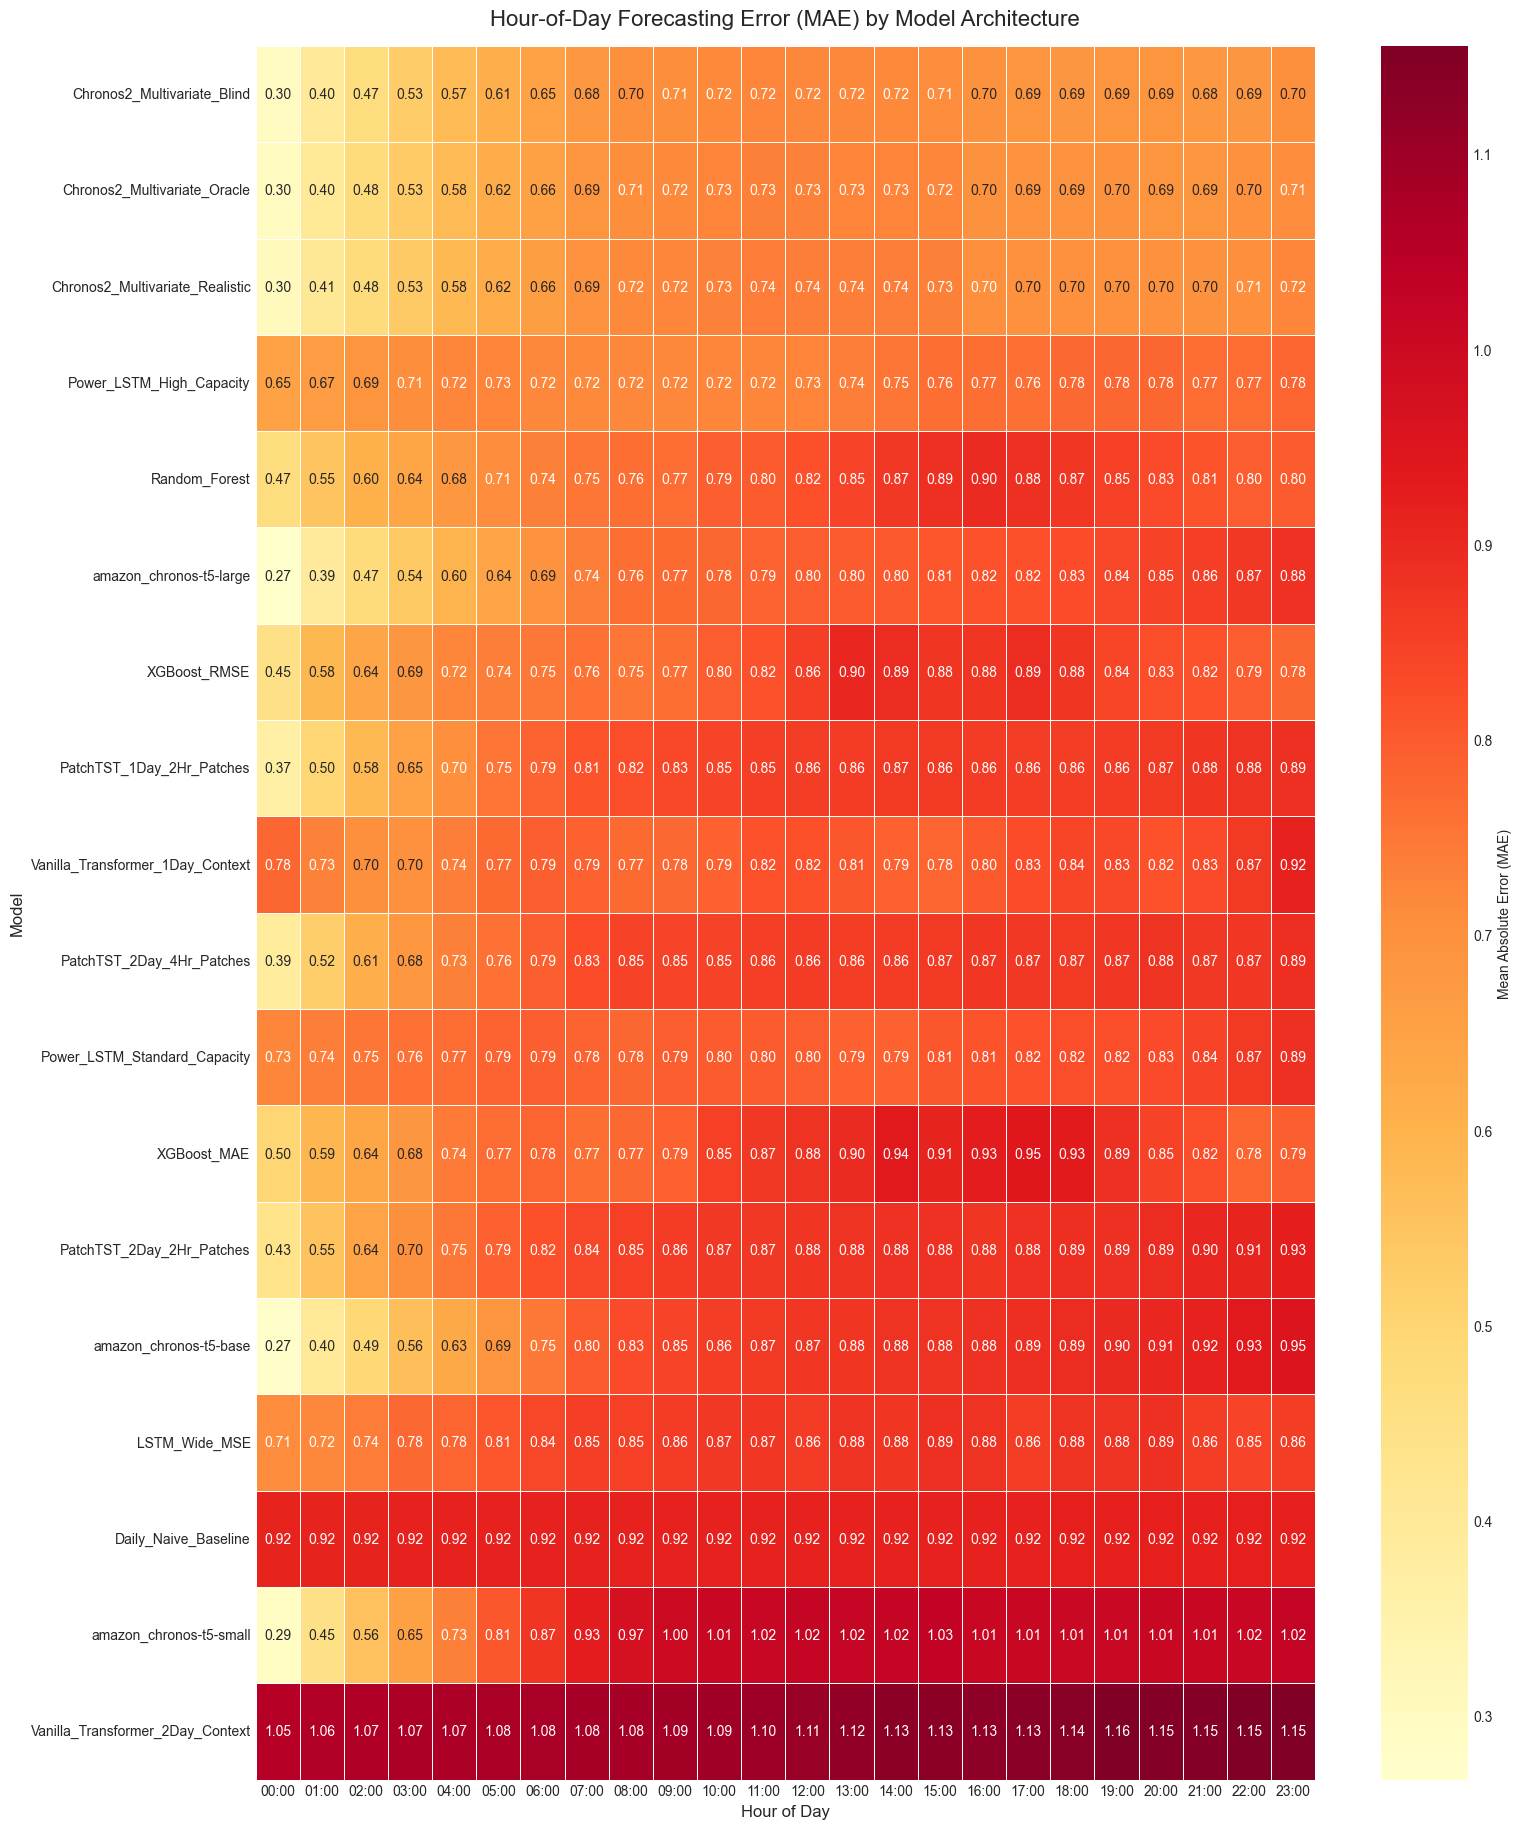


 TREE FEATURE IMPORTANCE:


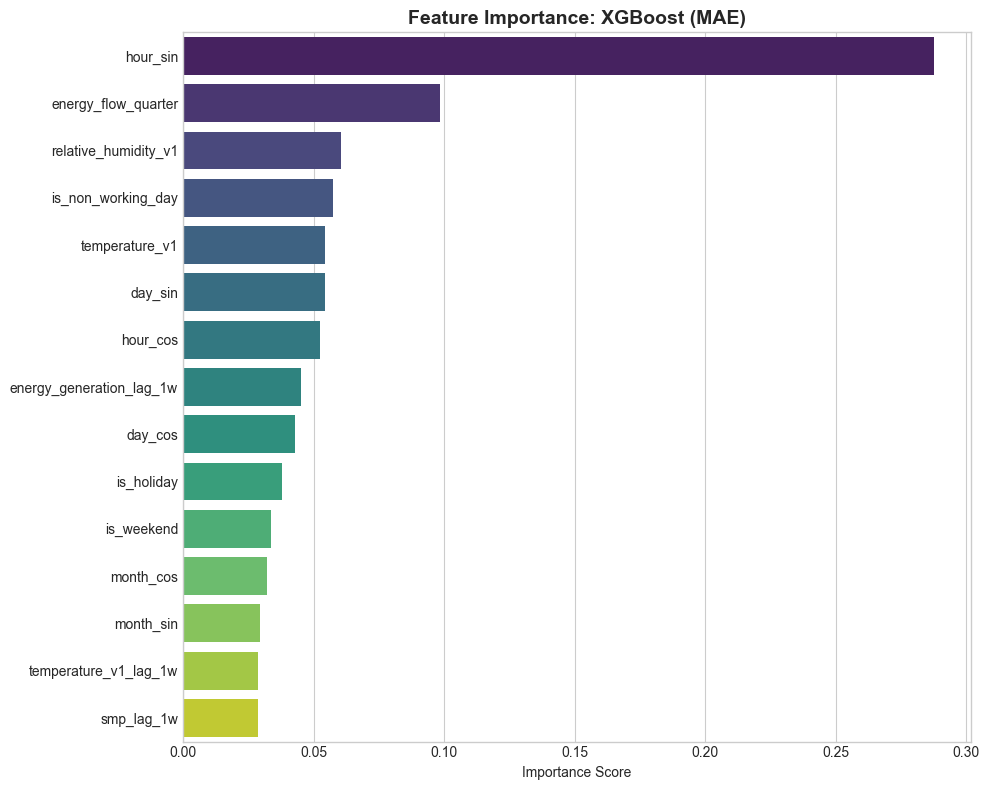

,Feature,Importance
0,hour_sin,0.287446
1,energy_flow_quarter,0.098322
2,relative_humidity_v1,0.060567
3,is_non_working_day,0.057461
4,temperature_v1,0.054527
5,day_sin,0.054522
6,hour_cos,0.052429
7,energy_generation_lag_1w,0.045265
8,day_cos,0.043044
9,is_holiday,0.037732


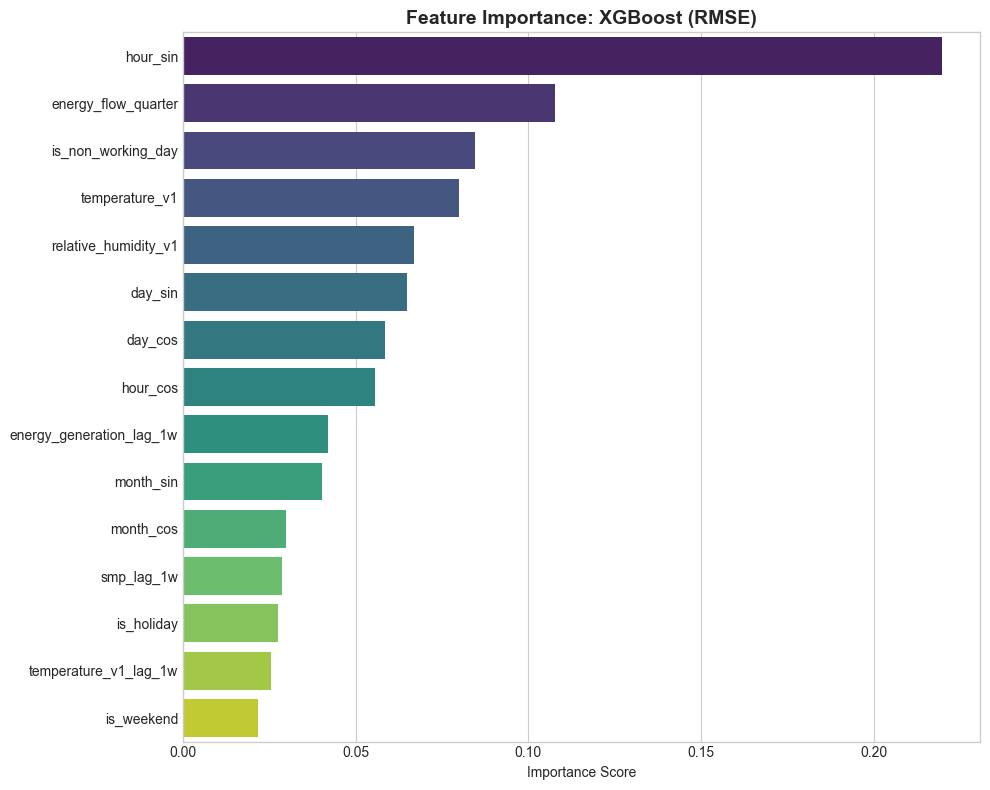

,Feature,Importance
0,hour_sin,0.219815
1,energy_flow_quarter,0.107788
2,is_non_working_day,0.084702
3,temperature_v1,0.079837
4,relative_humidity_v1,0.066800
5,day_sin,0.064795
6,day_cos,0.058608
7,hour_cos,0.055725
8,energy_generation_lag_1w,0.041891
9,month_sin,0.040207


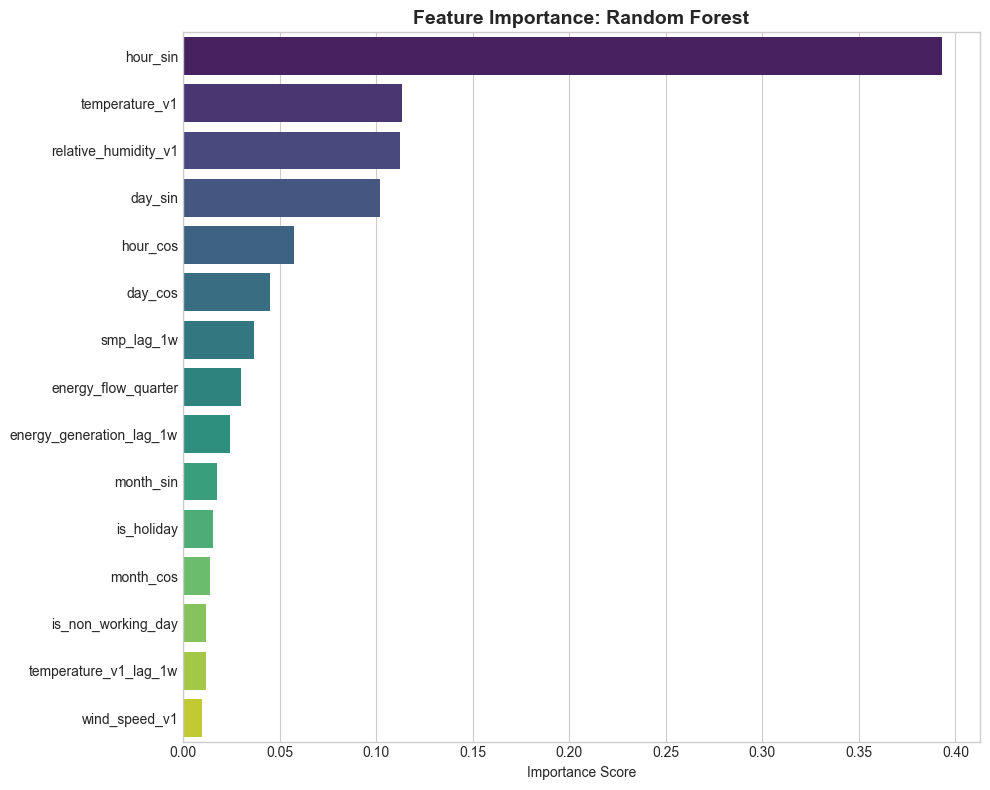

,Feature,Importance
0,hour_sin,0.393089
1,temperature_v1,0.113612
2,relative_humidity_v1,0.112165
3,day_sin,0.102240
4,hour_cos,0.057412
5,day_cos,0.045250
6,smp_lag_1w,0.036606
7,energy_flow_quarter,0.030051
8,energy_generation_lag_1w,0.024143
9,month_sin,0.017656



 PROBABILISTIC FORECASTS:


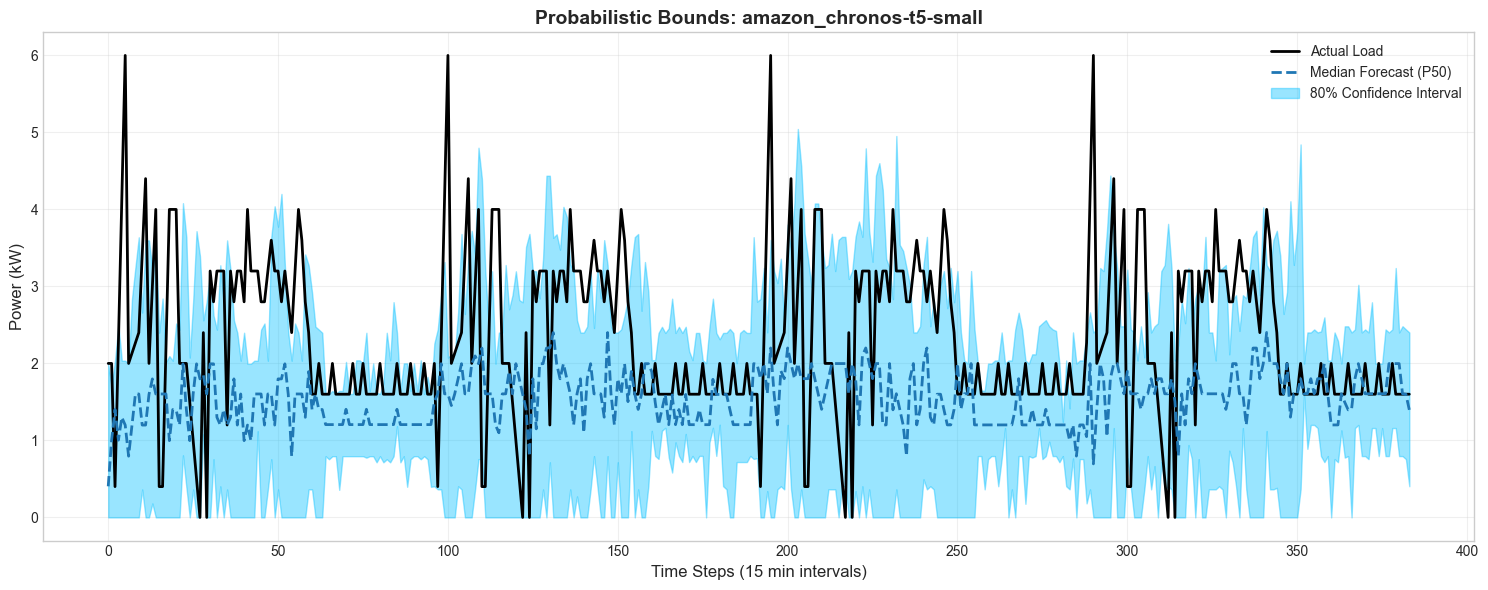

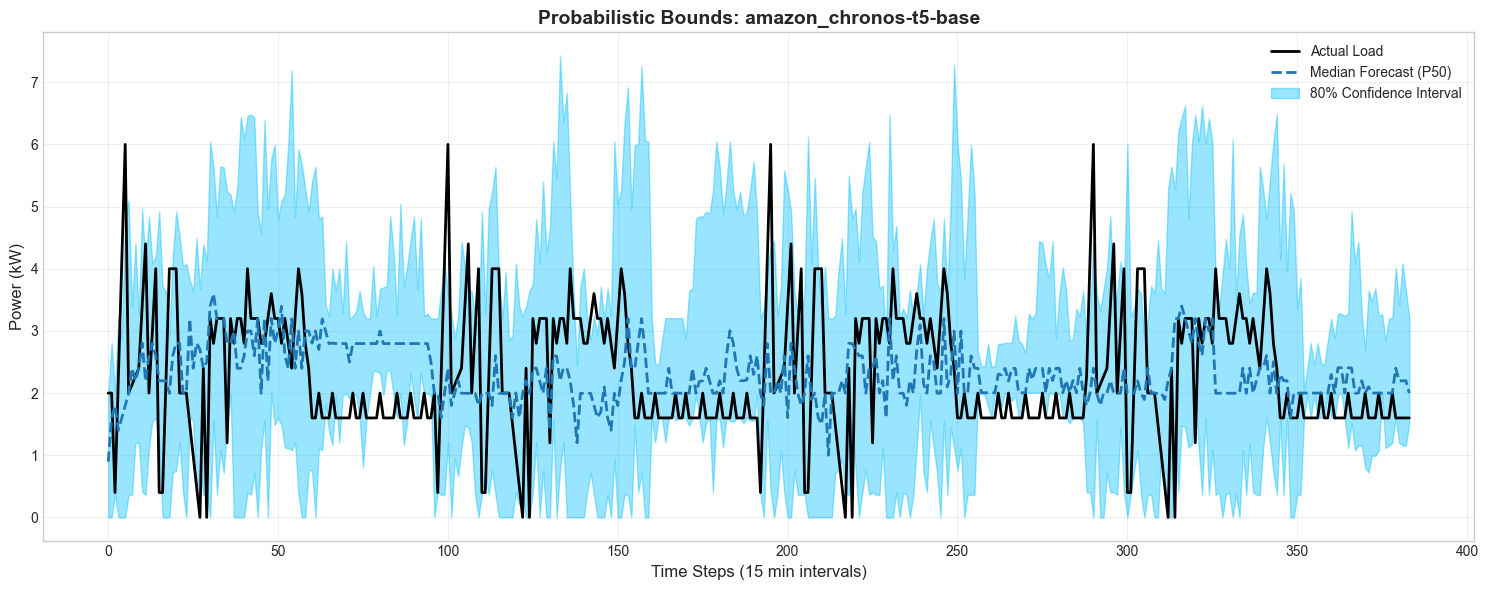

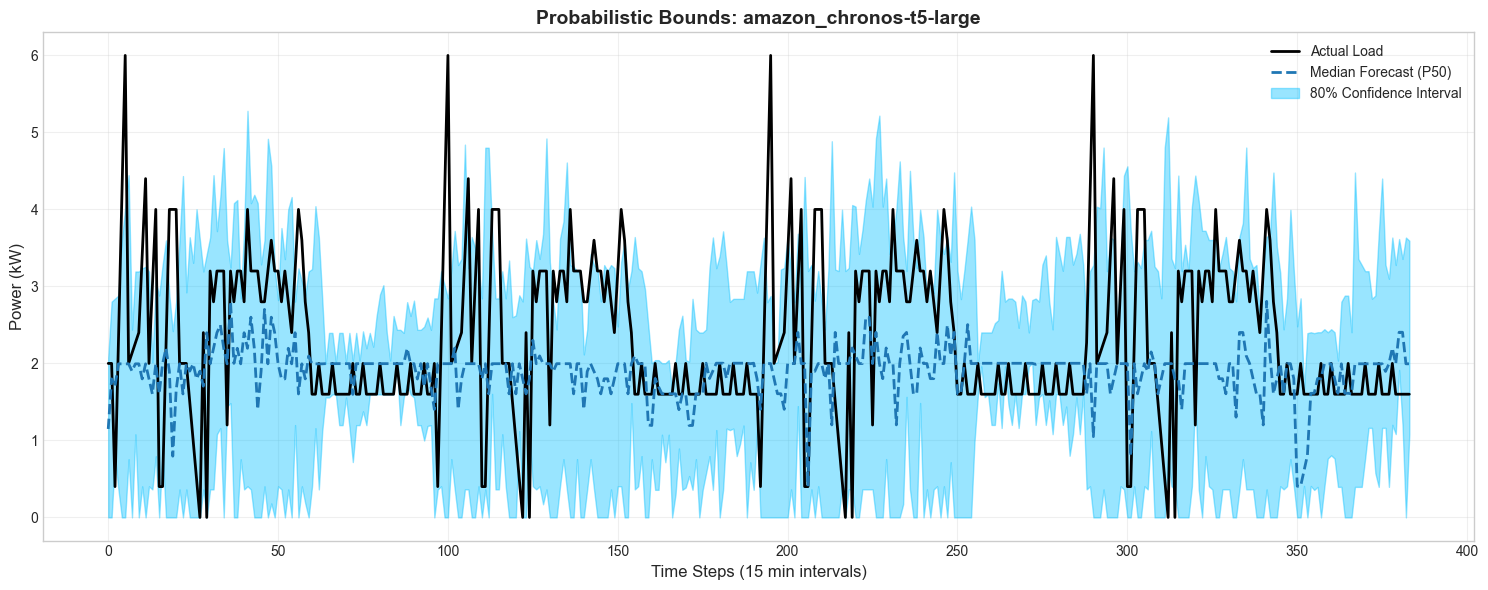

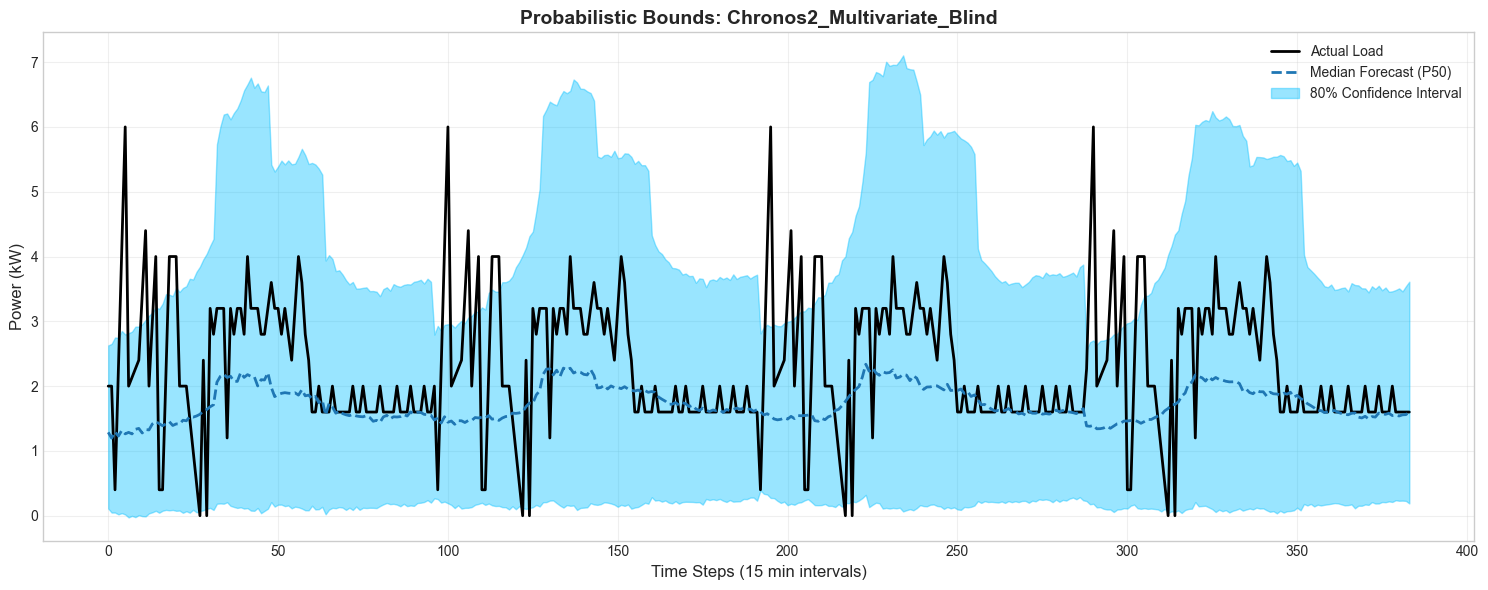

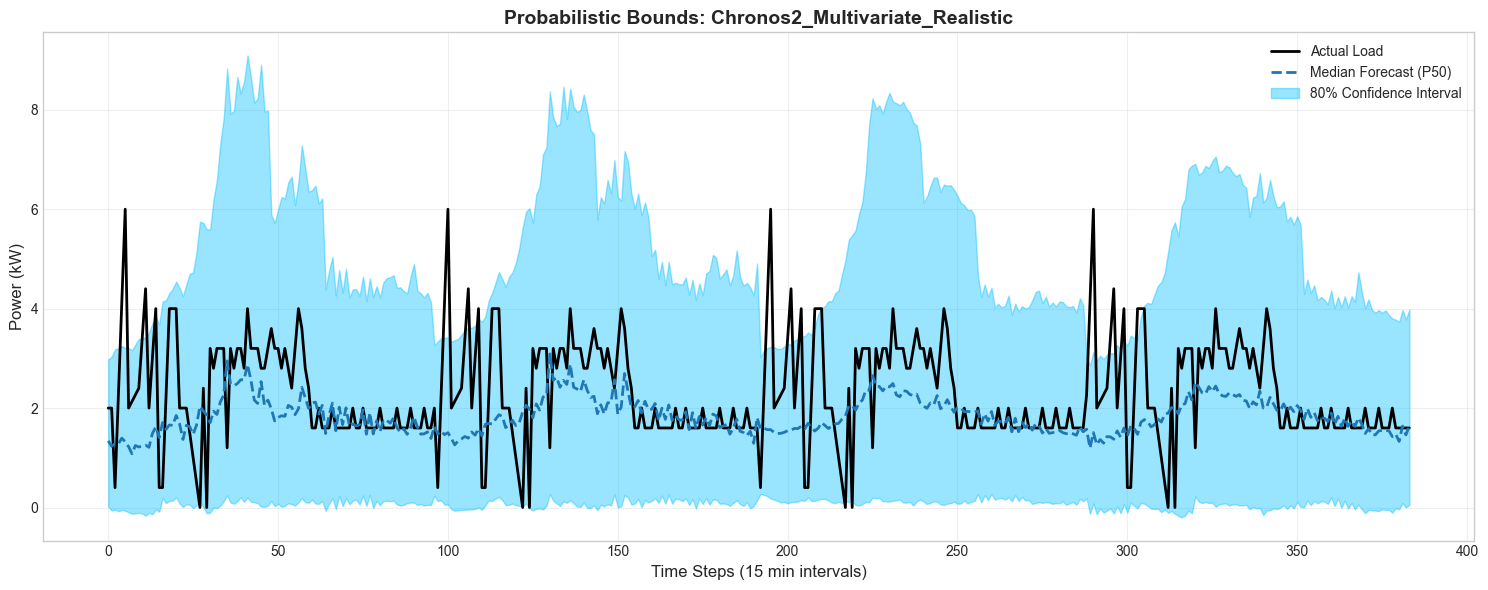

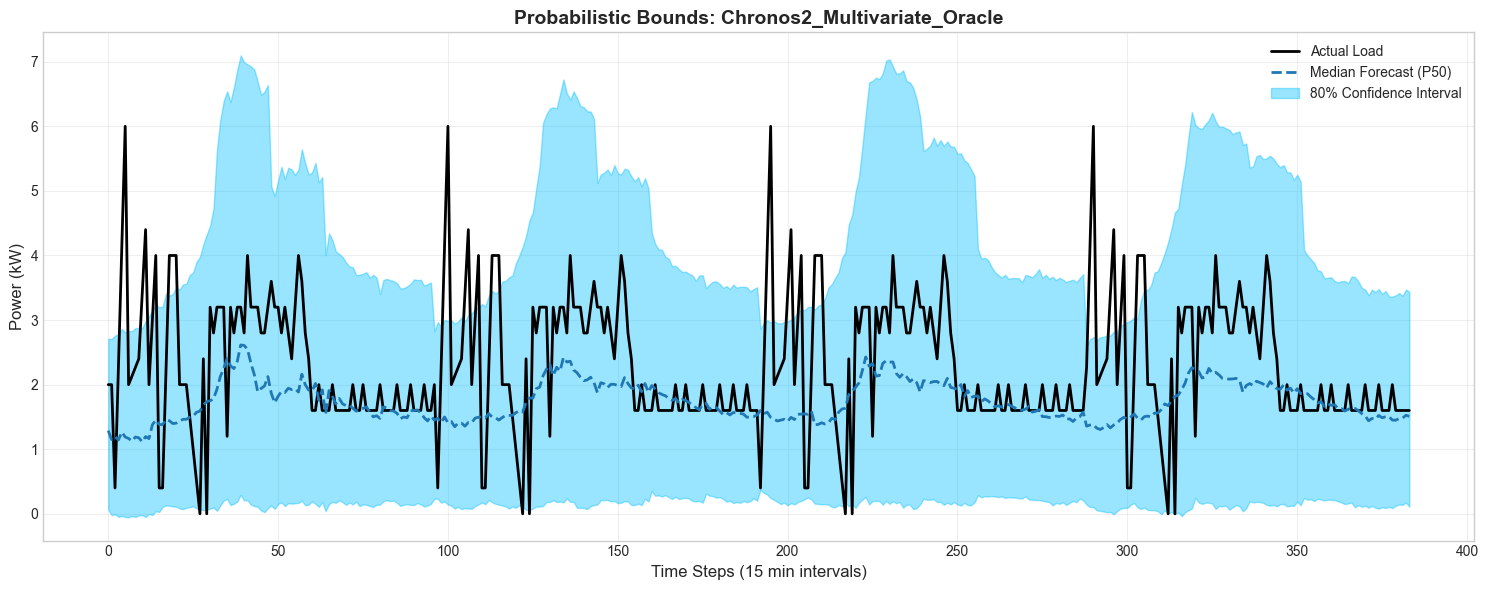


 RESIDUAL DIAGNOSTICS: Chronos2_Multivariate_Blind
Systematic Bias (Mean Error): -0.0153
Shapiro-Wilk Normality p-value: 0.0000e+00


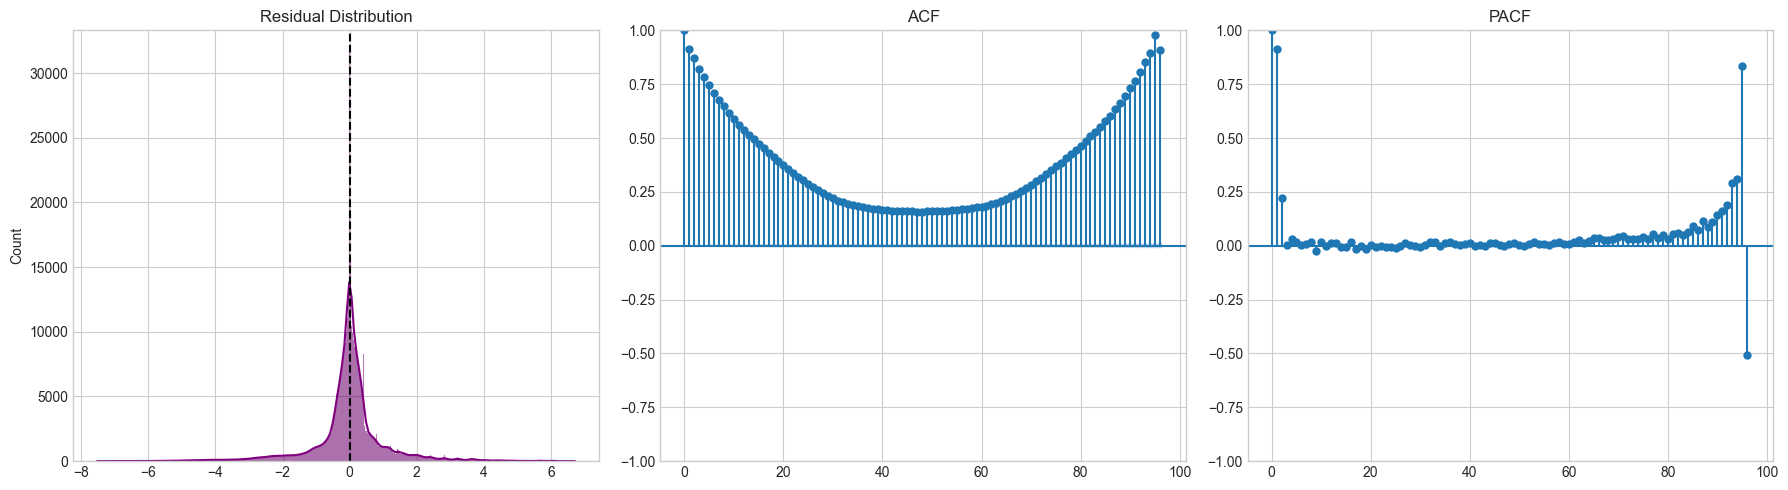


ALIGNING ARRAYS & EXECUTING DIEBOLD-MARIANO

Statistical Significance Testing
Reference Model: Chronos2_Multivariate_Blind


,Evaluated_Model,DM_Statistic,Raw_p_value,Corrected_p_value,Statistically_Significant,Superior_Model
8,PatchTST_2Day_4Hr_Patches,-22.680712,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
14,Daily_Naive_Baseline,-34.492942,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
13,LSTM_Wide_MSE,-25.962344,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
12,amazon_chronos-t5-base,-21.281932,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
11,PatchTST_2Day_2Hr_Patches,-26.497127,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
10,XGBoost_MAE,-21.406777,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
9,Power_LSTM_Standard_Capacity,-21.439464,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
15,amazon_chronos-t5-small,-32.260638,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
16,Vanilla_Transformer_2Day_Context,-46.682048,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
6,PatchTST_1Day_2Hr_Patches,-21.842249,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind


,Evaluated_Model,DM_Statistic,Raw_p_value,Corrected_p_value,Statistically_Significant,Superior_Model
8,PatchTST_2Day_4Hr_Patches,-22.680712,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
14,Daily_Naive_Baseline,-34.492942,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
13,LSTM_Wide_MSE,-25.962344,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
12,amazon_chronos-t5-base,-21.281932,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
11,PatchTST_2Day_2Hr_Patches,-26.497127,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
10,XGBoost_MAE,-21.406777,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
9,Power_LSTM_Standard_Capacity,-21.439464,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
15,amazon_chronos-t5-small,-32.260638,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
16,Vanilla_Transformer_2Day_Context,-46.682048,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind
6,PatchTST_1Day_2Hr_Patches,-21.842249,0.000000e+00,0.000000e+00,True,Chronos2_Multivariate_Blind


In [15]:
# LEADERBOARD COMPILATION

print(f"\n EVALUATION METRICS TABLE FOR ({HORIZON_NAME})")
results_df = pd.DataFrame(horizon_metrics)

if 'Model' in results_df.columns:
    results_df = results_df.drop_duplicates(subset=['Model'], keep='last')
if 'MASE' in results_df.columns:
    results_df = results_df.sort_values(by="MASE").reset_index(drop=True)

save_path = f"../results/{HORIZON_NAME}/leaderboard.csv"
results_df.to_csv(save_path, index=False)
print(f"Leaderboard successfully saved to {save_path}")

display_df = results_df.copy()
time_col = next((col for col in display_df.columns if "Time" in col or "time" in col.lower()), None)
numeric_cols = display_df.select_dtypes(include=['float64', 'float32']).columns

for col in numeric_cols:
    if col != time_col: display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")
if time_col and display_df[time_col].dtype in ['float64', 'float32']:
    display_df[time_col] = display_df[time_col].apply(lambda x: f"{x:.2f} s")

display(display_df)


# CACHE LOADER

model_results_dict = {}

for model_name in results_df["Model"]:
    cache_path_npz = f"../results/{HORIZON_NAME}/{model_name}/predictions.npz"
    
    # A. Deep Learning & Chronos (.npz)
    if os.path.exists(cache_path_npz):
        loaded = np.load(cache_path_npz)
        model_data = {'y_test_real': loaded['y_test_real'], 'predictions': loaded['predictions']}
        if 'lower_bounds' in loaded:
            model_data['lower_bounds'] = loaded['lower_bounds']
            model_data['upper_bounds'] = loaded['upper_bounds']
        model_results_dict[model_name] = model_data
        
    # B. Tree Models (.joblib via on-the-fly prediction)
    elif "XGBoost" in model_name or "Random_Forest" in model_name:
        if "MAE" in model_name: joblib_path = f"../results/{HORIZON_NAME}/{model_name}/xgboost_mae_model.joblib"
        elif "RMSE" in model_name: joblib_path = f"../results/{HORIZON_NAME}/{model_name}/xgboost_rmse_model.joblib"
        else: joblib_path = f"../results/{HORIZON_NAME}/{model_name}/random_forest_model.joblib"
            
        if os.path.exists(joblib_path):
            cached_model = joblib.load(joblib_path)
            test_preds = cached_model.predict(X_test_tree)
            orig_shape = test_preds.shape
            test_preds_unscaled = dl_scaler_targ.inverse_transform(test_preds.reshape(-1, 1)).reshape(orig_shape)
            model_results_dict[model_name] = {'y_test_real': y_test_unscaled, 'predictions': test_preds_unscaled}
            
    # C. Daily Naive (Mathematical Shift)
    elif "Naive" in model_name:
        naive_preds = run_daily_naive(y_test_unscaled, horizon=HORIZON_STEPS)
        model_results_dict[model_name] = {'y_test_real': y_test_unscaled, 'predictions': naive_preds}


# THE HEATMAP

print("\n HEATMAP")
if model_results_dict:
    master_error_df = plot_hourly_error_heatmap(model_results_dict)


# DEFINE STATISTICAL FUNCTIONS

def plot_probabilistic_forecast(y_true, y_pred_median, lower_bound, upper_bound, model_name, days_to_plot=4):
    horizon_steps = config.HORIZON_STEPS[config.ACTIVE_HORIZON]
    num_steps = horizon_steps * days_to_plot
    plt.figure(figsize=(15, 6))
    x_axis = np.arange(num_steps)
    
    plt.plot(x_axis, y_true.flatten()[:num_steps], label="Actual Load", color="black", linewidth=2)
    plt.plot(x_axis, y_pred_median.flatten()[:num_steps], label="Median Forecast (P50)", color="#1f77b4", linestyle="--", linewidth=2)
    plt.fill_between(x_axis, lower_bound.flatten()[:num_steps], upper_bound.flatten()[:num_steps], color='#00BFFF', alpha=0.4, label="80% Confidence Interval")
    
    plt.title(f"Probabilistic Bounds: {model_name}", fontsize=14, fontweight='bold')
    plt.xlabel(f"Time Steps ({config.ACTIVE_HORIZON.replace('_', ' ')} intervals)", fontsize=12)
    plt.ylabel("Power (kW)", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_tree_feature_importance(trained_model, feature_names, top_n=15, model_title="XGBoost"):
    if hasattr(trained_model, 'estimators_'): importances = np.mean([e.feature_importances_ for e in trained_model.estimators_], axis=0)
    elif hasattr(trained_model, 'feature_importances_'): importances = trained_model.feature_importances_
    
    indices = np.argsort(importances)[::-1][:top_n]
    top_features, top_importances = [feature_names[i] for i in indices], importances[indices]
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=top_importances, y=top_features, palette="viridis")
    plt.title(f"Feature Importance: {model_title}", fontsize=14, fontweight='bold')
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
    return pd.DataFrame({"Feature": top_features, "Importance": top_importances})

def analyze_residuals(y_true, y_pred, model_name, lags):
    residuals = y_true.flatten() - y_pred.flatten()
    print(f"\n RESIDUAL DIAGNOSTICS: {model_name}")
    print(f"Systematic Bias (Mean Error): {np.mean(residuals):.4f}")
    
    stat, p_value = stats.shapiro(np.random.choice(residuals, min(4000, len(residuals)), replace=False))
    print(f"Shapiro-Wilk Normality p-value: {p_value:.4e}")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(residuals, kde=True, ax=axes[0], color='purple').set_title("Residual Distribution")
    axes[0].axvline(0, color='black', linestyle='--')
    sm.graphics.tsa.plot_acf(residuals, lags=lags, ax=axes[1], title="ACF")
    sm.graphics.tsa.plot_pacf(residuals, lags=lags, ax=axes[2], title="PACF")
    plt.tight_layout()
    plt.show()


# TREE FEATURES & PROBABILISTICS

print("\n TREE FEATURE IMPORTANCE:")
tree_feature_names = ["hour_sin", "hour_cos", "day_sin", "day_cos", "month_sin", "month_cos", "is_holiday", "is_weekend", "is_non_working_day", "energy_flow_quarter", "temperature_v1", "relative_humidity_v1", "wind_speed_v1", "clouds_v1", "energy_consumption_lag_1w", "energy_generation_lag_1w", "smp_lag_1w", "temperature_v1_lag_1w"]

for m in [{"folder": "XGBoost_MAE", "file": "xgboost_mae_model.joblib", "title": "XGBoost (MAE)"}, {"folder": "XGBoost_RMSE", "file": "xgboost_rmse_model.joblib", "title": "XGBoost (RMSE)"}, {"folder": "Random_Forest", "file": "random_forest_model.joblib", "title": "Random Forest"}]:
    try: display(plot_tree_feature_importance(joblib.load(f"../results/{HORIZON_NAME}/{m['folder']}/{m['file']}"), tree_feature_names, 15, m["title"]))
    except: pass

print("\n PROBABILISTIC FORECASTS:")
for m in ["amazon_chronos-t5-small", "amazon_chronos-t5-base", "amazon_chronos-t5-large", "Chronos2_Multivariate_Blind", "Chronos2_Multivariate_Realistic", "Chronos2_Multivariate_Oracle"]:
    if m in model_results_dict and 'lower_bounds' in model_results_dict[m]:
        plot_probabilistic_forecast(model_results_dict[m]['y_test_real'], model_results_dict[m]['predictions'], model_results_dict[m]['lower_bounds'], model_results_dict[m]['upper_bounds'], m)


# DIAGNOSTICS & DIEBOLD-MARIANO

best_model_name = results_df.iloc[0]["Model"]
if best_model_name in model_results_dict:
    analyze_residuals(model_results_dict[best_model_name]['y_test_real'], model_results_dict[best_model_name]['predictions'], best_model_name, HORIZON_STEPS)

print("\nALIGNING ARRAYS & EXECUTING DIEBOLD-MARIANO")
min_windows = min([data['predictions'].shape[0] for data in model_results_dict.values()])
for model, data in model_results_dict.items():
    model_results_dict[model]['predictions'] = data['predictions'][-min_windows:]
    model_results_dict[model]['y_test_real'] = data['y_test_real'][-min_windows:]

statistical_report_df = run_statistical_significance_tests(
    model_results_dict=model_results_dict, best_model_name=best_model_name, alpha=0.05
)

display(statistical_report_df)